## Set Up

In [1]:
#%pip install pandas
#%pip install numpy
#%pip install matplotlib
#%pip install seaborn
#%pip install scipy
#%pip install scikit-posthocs

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

from Programs.functions import frequency_calc, severity_calc

## Preparing Data

### Reading Data

In [3]:
# Reading in Data
df = pd.read_csv(Path.cwd() / "Data" / "Raw" / "insurance_dataset.csv",
                 dtype={"is_capped_incurred":"Int64",
                        "bi_count":"Int64",
                        "ad_count":"Int64",
                        "pd_count":"Int64",
                        "th_count":"Int64",
                        "ws_count":"Int64",
                        "vehicle_age":"Int64"})

# Converting dates and times
df["start_date"] = pd.to_datetime(df["start_date"], format = "%d/%m/%Y")

#first removing values from 1753
df["vehicle_purchase_date"] = (
    df["vehicle_purchase_date"]
        .where(~df["vehicle_purchase_date"].str.contains("1753", na = False))
)                                     
df["vehicle_purchase_date"] = pd.to_datetime(df["vehicle_purchase_date"], format = "%d/%m/%Y")

df["licence_test_date"] = pd.to_datetime(df["licence_test_date"], format = "%d/%m/%Y")

### Profiling Missing Data 1

In [4]:
# Profiling missing values
missing_values_before = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_before.to_csv(Path.cwd() / "Reports" / "missing_values_before.csv", index=False)

### Difficult Data Quality Issues

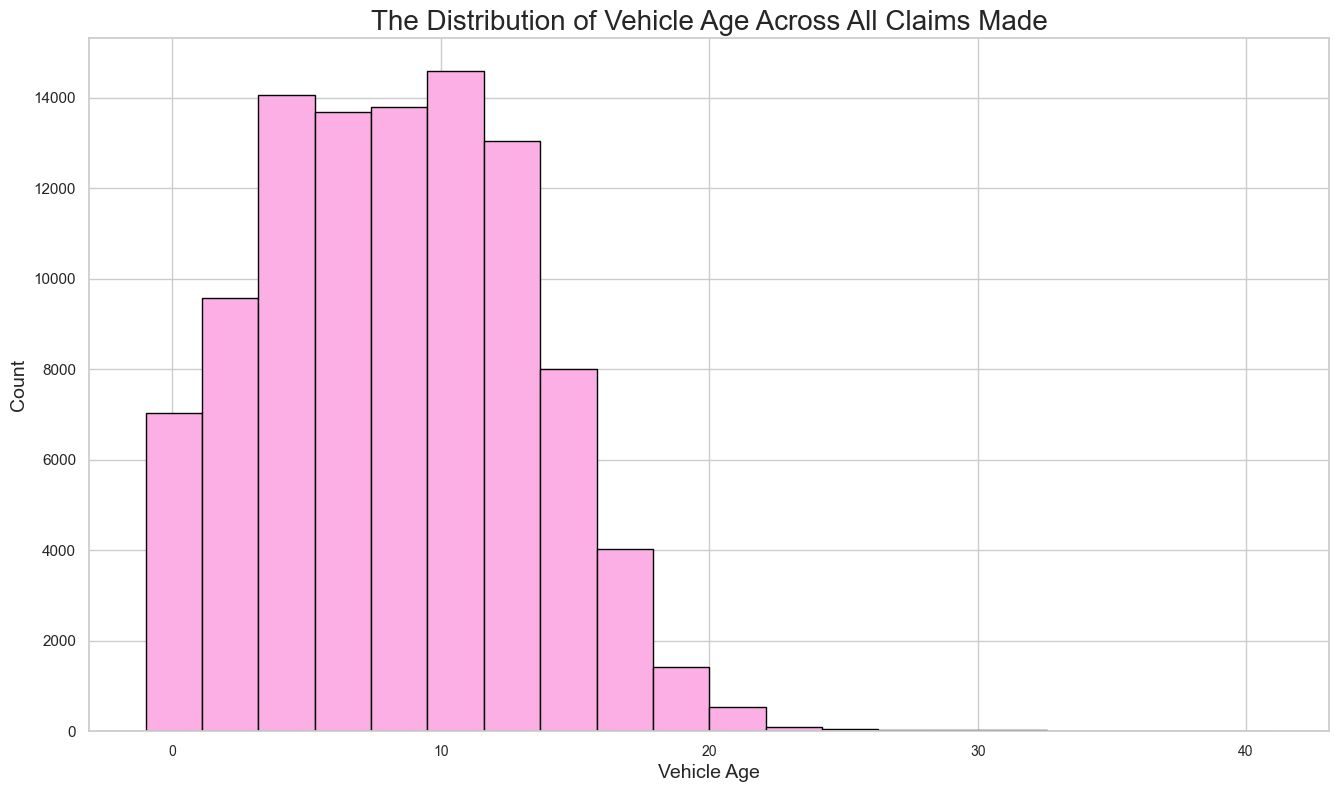

In [5]:
fig = plt.figure(figsize = (16,9))

sns.set_theme(style = "whitegrid")

plt.hist(df["vehicle_age"],
        edgecolor = "black",
        bins = 20,
        color = sns.color_palette("colorblind")[6])

plt.xlabel("Vehicle Age", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.title("The Distribution of Vehicle Age Across All Claims Made", fontsize = 20)
plt.xticks(fontsize = 10)

plt.show()

sns.set_theme(style = "whitegrid")

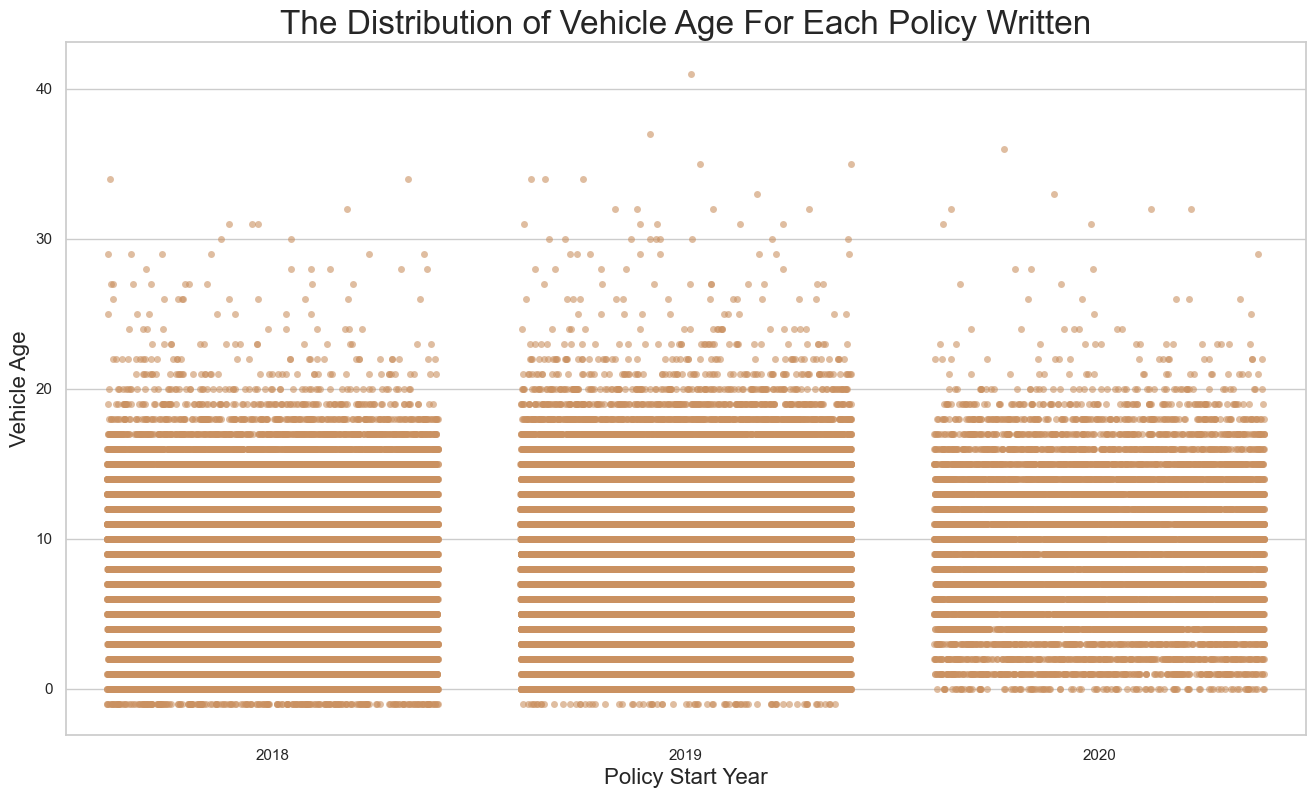

In [6]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "vehicle_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[5])

plt.xlabel("Policy Start Year", fontsize = 16),
plt.ylabel("Vehicle Age", fontsize = 16)
plt.title("The Distribution of Vehicle Age For Each Policy Written", fontsize = 24)

plt.show()

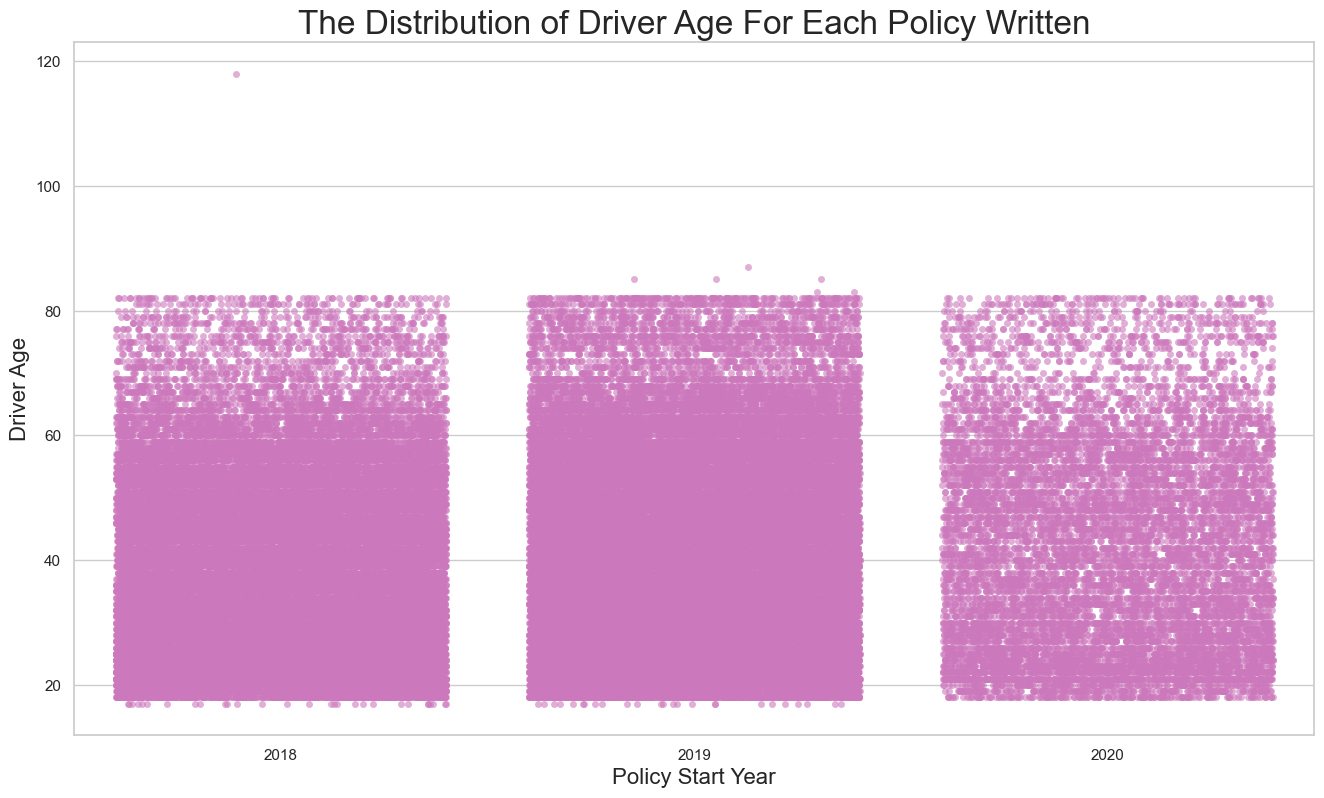

In [7]:
fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "d1_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[4])

plt.xlabel("Policy Start Year", fontsize = 16),
plt.ylabel("Driver Age", fontsize = 16)
plt.title("The Distribution of Driver Age For Each Policy Written", fontsize = 24)

plt.show()

In [8]:
neg_incurred = (
    (df.loc[:, list(df.columns[df.columns.str.endswith("incurred")][1:])] < 0)
        .sum()
        .reset_index()
        .rename(columns = {"index":"Column", 0:"Total Negative Values"})
        .sort_values("Total Negative Values", ascending = False)
)

neg_incurred
#neg_incurred.to_csv(Path.cwd() / "Reports" / "negative_incurred.csv", index = False)

,Column,Total Negative Values
3,ad_incurred,1715
0,incurred,1073
1,capped_incurred,1073
4,pd_incurred,6
5,th_incurred,1
2,bi_incurred,0
6,ws_incurred,0


### Replacing Values

In [9]:
## Replacing Values

#Cleaning up the name of business providers
df["business_provider"] = df["business_provider"].str.replace({" ":"",
                                                               "+":"and",
                                                               "DefaultDefault":"Default",
                                                               "DefaultCampaign":"Default"})


#Replacing age 118 with NaN
df["d1_age"] = df["d1_age"].where(df["d1_age"] != 118)

df["d1_residency_years"] = df["d1_residency_years"].where(df["d1_residency_years"] != 118)

#Replacing NA with 0
df["incurred"] = df["incurred"].fillna(0)
df["capped_incurred"] = df["capped_incurred"].fillna(0)
df["bi_incurred"] = df["bi_incurred"].fillna(0)
df["ad_incurred"] = df["ad_incurred"].fillna(0)
df["pd_incurred"] = df["pd_incurred"].fillna(0)
df["th_incurred"] = df["th_incurred"].fillna(0)
df["ws_incurred"] = df["ws_incurred"].fillna(0)

df["bi_count"] = df["bi_count"].fillna(0)
df["ad_count"] = df["ad_count"].fillna(0)
df["pd_count"] = df["pd_count"].fillna(0)
df["th_count"] = df["th_count"].fillna(0)
df["ws_count"] = df["ws_count"].fillna(0)

df["is_capped_incurred"] = df["is_capped_incurred"].fillna(0)


#Calculating absolute values of all negative "incurred" values and Recalculating the incurred column
df["ad_incurred"] = df["ad_incurred"].abs()
df["th_incurred"] = df["th_incurred"].abs()
df["pd_incurred"] = df["pd_incurred"].abs()

df["incurred"] = df["ad_incurred"] + df["bi_incurred"] + df["pd_incurred"] + df["th_incurred"] + df["ws_incurred"]

df["capped_incurred"] = np.select(
    [
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] < 50000),
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] >= 50000)
    ],
    [
        df["incurred"],
        50000
    ],
    df["capped_incurred"]
)    


#Filling in NAs for net_earned_premium
df["net_earned_premium"] = df["net_earned_premium"].where(~df["net_earned_premium"].isna(),
                                                         df["net_written_premium"] * df["exposure"])


#Replacing negatives values with NaN
df["vehicle_age"] = df["vehicle_age"].where(df["vehicle_age"] >= 0)

#df["ad_incurred"] = df["ad_incurred"].where(df["ad_incurred"] >= 0)

#df["th_incurred"] = df["th_incurred"].where(df["th_incurred"] >= 0)

#df["incurred"] = df["incurred"].where(df["incurred"] >= 0)

#df["capped_incurred"] = df["capped_incurred"].where(df["capped_incurred"] >= 0)


## Changing Casing
df["vehicle_make"] = df["vehicle_make"].str.title()

df["transmission"] = df["transmission"].str.title()

### Checking Duplicates

In [10]:
# Checking for duplicate rows
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print(f"{df.duplicated().sum()} rows are duplicated")

print(f"{df["id"].duplicated().sum()} ID values are duplicated")


Dataset has 100000 rows and 41 columns
0 rows are duplicated
0 ID values are duplicated


### Checking Values

In [11]:
# Checking column values
#df.groupby("ws_incurred").groups.keys()

#### Looking at the values in each column, below are issues that should be addressed:

*Data Types*
- is_capped_incurred is float
- bi_count is float
- ad_count is float
- pd_count is float
- th_count is float
- ws_count is float
- vehicle_age is float

*Numeric Values*
- ad_incurred has negative values
- th_incurred has negative values
- incurred has negative values
- capped_incurred has negative values
- d1_age contains "118" values.
- d1_residency_years contains "118" values
- vehicle_value has a range of values, including single digits (not decided)
- vehicle_age contains negative values

*Character Values*
- business_provider has multiple formats for values (may be more work)
- vehicle_make is all capitalised
- transmission is all capitalised

### Profiling Missing Data 2

In [12]:
# Profiling missing values
missing_values_after = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_after.to_csv(Path.cwd() / "Reports" / "missing_values_after.csv", index=False)

In [13]:
#Adding new column for 'Driving Years'
#Notice there are some minus values, perhaps they are just prepared

#df["days_driving"] = df["start_date"] - df["licence_test_date"]
df["years_driving"] = (df["start_date"] - df["licence_test_date"]) / pd.Timedelta(days=365.25)

df["experience_group"] = pd.cut(
    df["years_driving"],
    bins=[
        -np.inf, 0,
        10, 20, 30,
        40, 50, 60,
        np.inf
    ],
    labels=[
        "<0 years",
        "0-10 years",
        "10-20 years",
        "20-30 years",
        "30-40 years",
        "40-50 years",
        "50-60 years",
        "60+ years"
    ]
)


df["vehicle_value_band"] = pd.cut(
    df["vehicle_value"],
    bins=[
        0,
        2000, 4000, 6000,
        8000, 10000, np.inf
    ],
    labels=[
        "£0-2000",
        "£2000-4000",
        "£4000-6000",
        "£6000-8000",
        "£8000-10000",
        "£10000+"
    ]
)

## High-Level Analysis

### Number of Policies Written

In [14]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

#policies = (
 #   df.groupby("start_year").id.count()
  #      .reset_index()
   #     .rename(columns = {"start_year":"Start Year", "id":"Number of Policies"})
#)

policies = (
    df.groupby("start_year")
    .agg(
        policies = ("id", "count"),
        first_date = ("start_date", "min"),
        last_date = ("start_date", "max")
    )
    .reset_index()
    .rename(columns = {
        "start_year":"Start Year",
        "policies":"Number of Policies",
        "first_date":"First Policy Date",
        "last_date":"Last Policy Date"
    }
           )
)

policies["First Policy Date"] = pd.to_datetime(policies["First Policy Date"], format = "%d-%m-%Y")

policies
#policies.to_csv(Path.cwd() / "Reports" / "policies.csv", index = False)

,Start Year,Number of Policies,First Policy Date,Last Policy Date
0,2018,38539,2018-04-01,2018-12-31
1,2019,49808,2019-01-01,2019-12-31
2,2020,11653,2020-01-01,2020-03-31


Policies written in 2020 could be low due to Covid and fewer people driving/more people working from home

### Frequency of Claims Counts

In [15]:
# Frequency of claims count
claim_frequency = pd.DataFrame(df.groupby("claim_count")
                               .id
                               .count()
                               .reset_index()
                               .rename(columns={"claim_count":"Claims Count",
                                                "id": "Frequency"}))

claim_frequency["Percentage"] = (claim_frequency["Frequency"] / claim_frequency["Frequency"].sum()) * 100
claim_frequency
# Exporting
#claim_frequency.to_csv("Reports/claim_frequency.csv", index=False)

,Claims Count,Frequency,Percentage
0,0,92581,92.581
1,1,6937,6.937
2,2,452,0.452
3,3,27,0.027
4,4,3,0.003


### Profit

In [16]:
# Calculating the total cost per person
df["final_incurred"] = np.where(df["is_capped_incurred"].fillna(0) == 1,
                                df["capped_incurred"],
                                df["incurred"])

# Calculating Profitability
df["profit"] = df["net_earned_premium"].fillna(0) - df["final_incurred"].fillna(0)

print(f"The gross earned premiums is {round(df["net_earned_premium"].sum(), 2)}")
print(f"The total incurred charges is {round(df["final_incurred"].sum(), 2)}")
print(f"Total profit made in this period is {round(df['profit'].sum(), 2)}")

profit = (
    df.groupby("start_year").agg(
        total_profit = ("profit", "sum"),
        mean_profit = ("profit", "mean")
    )
    .reset_index()
    .rename(columns = {"start_year":"Start Year",
                       "total_profit":"Total Profit (millions)",
                       "mean_profit":"Mean Profit"})
)
profit["Total Profit (millions)"] = round(profit["Total Profit (millions)"] / 1000000, 2)
profit["Mean Profit"] = round(profit["Mean Profit"], 2)

profit
#profit.to_csv(Path.cwd() / "Reports" / "profit.csv", index = False)

The gross earned premiums is 27237225.85
The total incurred charges is 19607094.15
Total profit made in this period is 7630131.7


,Start Year,Total Profit (millions),Mean Profit
0,2018,3.43,89.05
1,2019,3.94,79.19
2,2020,0.25,21.77


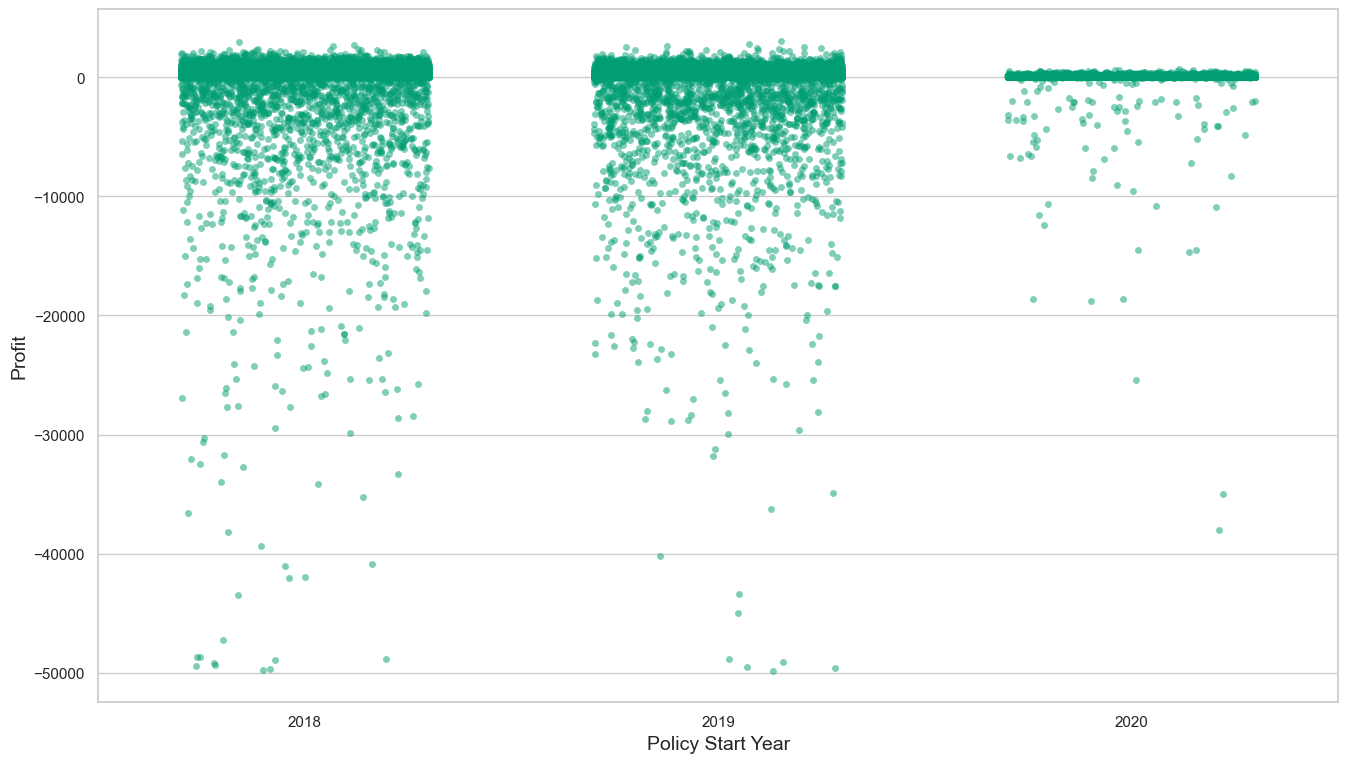

In [17]:
fig = plt.figure(figsize = (16,9))

sns.stripplot(data = df,
            x = "start_year",
            y = "profit",
            jitter = 0.3,
            alpha = 0.5,
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("Profit", fontsize = 14)

plt.show()

### FREQUENCY AND SEVERITY

In [18]:
# Calculating Claims Frequency
claims_frequency = df["claim_count"].sum() / df["exposure"].sum()

print(f"The total number of claims is {df["claim_count"].sum()}")
print(f"The total number of vehicles vehicle-years at risk is {round(df['exposure'].sum(), 2)}")
print(f"The claims frequency is {round(claims_frequency, 2)} claims per year")

frequency = (
    df.groupby("start_year")[["exposure", "claim_count"]]
        .sum()
)
frequency["frequency"] = round(frequency["claim_count"] / frequency["exposure"], 6)

#frequency.to_csv(Path.cwd () / "Reports" / "frequency.csv", index = False)

The total number of claims is 7934
The total number of vehicles vehicle-years at risk is 71959.47
The claims frequency is 0.11 claims per year


In [19]:
severity = (
    df.groupby("start_year")
      .agg(
          total_incurred=("final_incurred", "sum"),
          total_claims=("claim_count", "sum")
      )
)

severity["severity"] = (
    severity["total_incurred"]
    / severity["total_claims"]
)
severity

,total_incurred,total_claims,severity
start_year,,,
2018,9942032.88,4065,2445.764546
2019,9127966.39,3700,2467.017943
2020,537094.88,169,3178.076213


In [20]:
freq_sev = (
    pd.merge(frequency, severity, left_on=frequency.index,right_on=severity.index)
        .drop(columns = "total_claims")
        .rename(columns = {"key_0":"start_year", "claim_count":"claims"})
        .iloc[:, [0, 2, 1, 4, 3, 5]]
)

freq_sev["pure_premium"] = freq_sev["frequency"] * freq_sev["severity"]

freq_sev

,start_year,claims,exposure,total_incurred,frequency,severity,pure_premium
0,2018,4065,34379.416438,9942032.88,0.118239,2445.764546,289.184754
1,2019,3700,35402.257134,9127966.39,0.104513,2467.017943,257.835446
2,2020,169,2177.800742,537094.88,0.077601,3178.076213,246.621892


In [21]:
freq_sev2 = freq_sev.merge(
    right = df.groupby("start_year").net_written_premium.mean().reset_index(),
    on = "start_year")

freq_sev2["added_on"] = freq_sev2["net_written_premium"] - freq_sev2["pure_premium"]

freq_sev2.columns = [
    "Start Year", "Claims", "Years at Risk", "Total Incurred", "Frequency", "Severity", "Pure Premium",
    "Net Written Premium", "Added On"
]

for col in freq_sev2.select_dtypes(include="number").columns:
    freq_sev2[col] = round(freq_sev2[col], 2)


freq_sev2
#freq_sev2.to_csv(Path.cwd() / "Reports" / "frequency_severity.csv", index = False)

,Start Year,Claims,Years at Risk,Total Incurred,Frequency,Severity,Pure Premium,Net Written Premium,Added On
0,2018,4065,34379.42,9942032.88,0.12,2445.76,289.18,380.11,90.92
1,2019,3700,35402.26,9127966.39,0.10,2467.02,257.84,355.31,97.47
2,2020,169,2177.80,537094.88,0.08,3178.08,246.62,350.22,103.60


In [22]:
#Frequency of each claim type
freq_sev_type = pd.DataFrame({
    "frequency": [
        df["bi_count"].sum() / df["exposure"].sum(),
        df["ad_count"].sum() / df["exposure"].sum(),
        df["pd_count"].sum() / df["exposure"].sum(),
        df["th_count"].sum() / df["exposure"].sum(),
        df["ws_count"].sum() / df["exposure"].sum()
    ],
    "severity": [
        df["bi_incurred"].sum() / df["bi_count"].sum(),
        df["ad_incurred"].sum() / df["ad_count"].sum(),
        df["pd_incurred"].sum() / df["pd_count"].sum(),
        df["th_incurred"].sum() / df["th_count"].sum(),
        df["ws_incurred"].sum() / df["ws_count"].sum()
    ]
}, index=["Bodily Injuries", "Accidental", "Third Party Property", "Fire/Theft", "Windscreen"])

freq_sev_type["pure_premium"] = freq_sev_type["frequency"] * freq_sev_type["severity"]

freq_sev_type = (
    freq_sev_type.sort_values("severity", ascending=False)
    .rename(columns = {
        "frequency":"Frequency",
        "severity":"Severity",
        "pure_premium":"Pure Premium"
    })
)

freq_sev_type["Frequency"] = round(freq_sev_type["Frequency"], 3)
freq_sev_type["Severity"] = round(freq_sev_type["Severity"], 2)
freq_sev_type["Pure Premium"] = round(freq_sev_type["Pure Premium"], 2)

freq_sev_type = (
    freq_sev_type.reset_index()
    .rename(columns = {"index":"Claim Type"})
)

freq_sev_type
#freq_sev_type.to_csv(Path.cwd() / "Reports" / "frequency_severity_by_type.csv", index = False)

,Claim Type,Frequency,Severity,Pure Premium
0,Bodily Injuries,0.012,8563.96,101.99
1,Fire/Theft,0.002,3774.47,8.60
2,Third Party Property,0.043,2618.57,111.50
3,Accidental,0.069,1005.31,69.06
4,Windscreen,0.026,105.13,2.78


## Profiling Customer Who Made Claims

### Number of Claims by Policy Year

In [23]:
# Calculating number of claims by start_year and the number of people making claims

yearly_claims = (
    pd.merge(left = df.groupby("start_year").claim_count.sum().reset_index(),
        right = df[df["claim_count"] > 0].groupby("start_year").id.count().reset_index(),
        on = "start_year")
    .rename(columns={"start_year":"Start Year",
                     "claim_count":"Total Claims",
                     "id":"Number of Customers",})
)

yearly_claims

,Start Year,Total Claims,Number of Customers
0,2018,4065,3767
1,2019,3700,3486
2,2020,169,166


### Average Claim Value by Year

In [24]:
# Subsetting customers that made claims
df_claimed = df[df["claim_count"] > 0]

print(f"{df_claimed.shape[0]} customers made a claim")

# Calculating the average cost per claim
df_claimed["mean_claim_value"] = df_claimed["final_incurred"] / df_claimed["claim_count"]

print(f"The average claim value is {round(df_claimed["mean_claim_value"].mean(), 2)}")

df_claimed.groupby("start_year").agg(
    mean_claim = ("mean_claim_value", "mean"),
    median_caim = ("mean_claim_value", "median")
)

7419 customers made a claim
The average claim value is 2470.89


,mean_claim,median_caim
start_year,,
2018,2435.877880,194.0
2019,2479.499081,230.1
2020,3084.603012,632.5


<Figure size 1600x900 with 0 Axes>

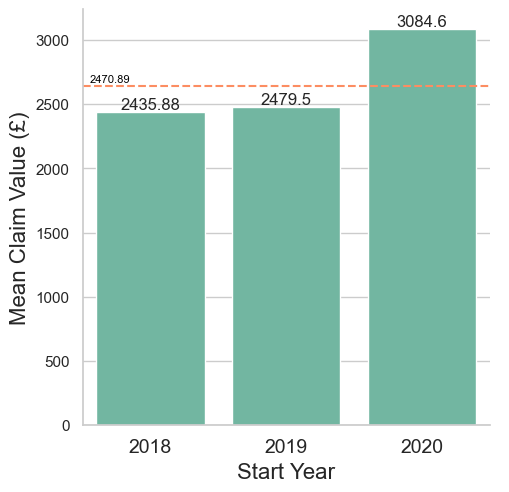

In [25]:
# Calculating the average claim cost each year
mean_claim_by_year = df_claimed.groupby("start_year").mean_claim_value.mean().reset_index()

fig = plt.figure(figsize=(16, 9))

sns.set_theme(style = "whitegrid")

sns.catplot(data = mean_claim_by_year,
            x = "start_year",
            y = "mean_claim_value",
            kind = "bar",
            color = sns.color_palette("Set2")[0])

plt.xlabel("Start Year", fontsize=16)
plt.ylabel("Mean Claim Value (£)", fontsize=16)
plt.xticks(fontsize=14)
plt.axhline(y=round(df_claimed["final_incurred"].mean(), 2),
            color = sns.color_palette("Set2")[1],
            linestyle="--")

plt.text(x=-0.45,
         y=round(df_claimed["mean_claim_value"].mean(), 2) + 200,
         s=str(round(df_claimed["mean_claim_value"].mean(), 2)),
         fontsize=8,
         color="black")

for i, v in enumerate(mean_claim_by_year["mean_claim_value"]):
    plt.text(i, v, str(round(v, 2)), ha = "center", va = "bottom")

plt.show()

In [26]:
kruskal(
    df_claimed.loc[df["start_year"] == 2018, "mean_claim_value"],
    df_claimed.loc[df["start_year"] == 2019, "mean_claim_value"],
    df_claimed.loc[df["start_year"] == 2020, "mean_claim_value"]
)

KruskalResult(statistic=np.float64(8.021622462314419), pvalue=np.float64(0.01811869082674319))

In [27]:
posthoc = sp.posthoc_dunn(
    df_claimed,
    val_col="mean_claim_value",
    group_col="start_year",
    p_adjust="holm"
)

print(posthoc)

          2018      2019      2020
2018  1.000000  0.201916  0.021795
2019  0.201916  1.000000  0.042628
2020  0.021795  0.042628  1.000000


### Number of High Claims

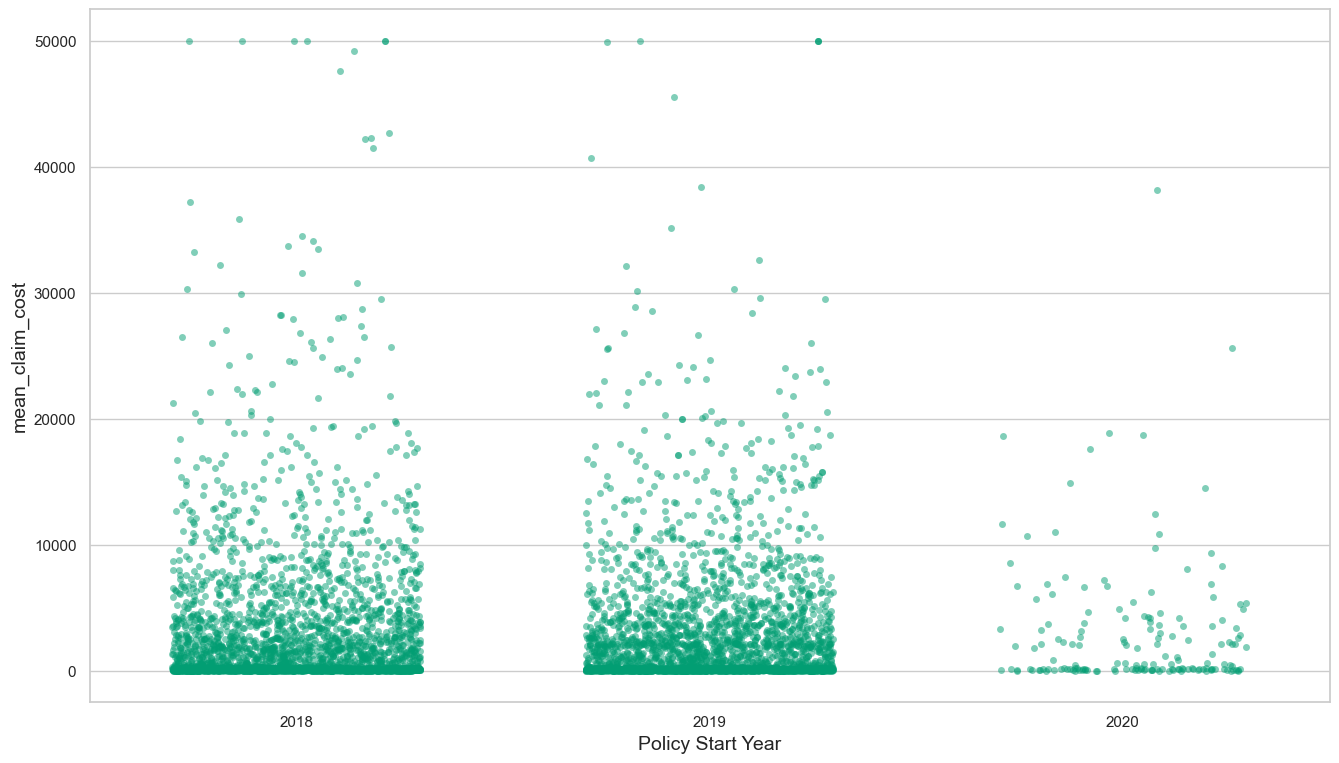

In [28]:
fig = plt.figure(figsize = (16,9))

sns.stripplot(data = df_claimed,
            x = "start_year",
            y = "mean_claim_value",
            jitter = 0.3,
            alpha = 0.5,
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("mean_claim_cost", fontsize = 14)

plt.show()

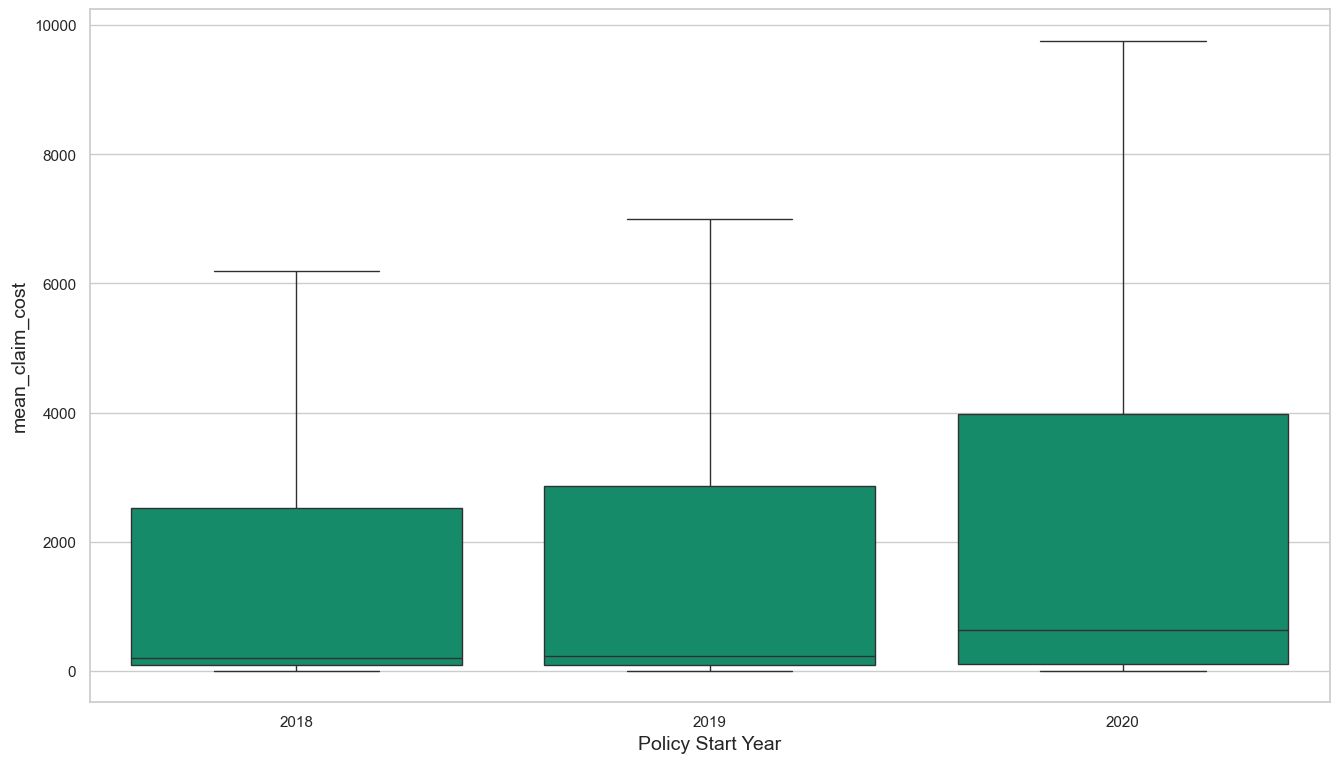

In [29]:
fig = plt.figure(figsize = (16,9))

sns.boxplot(data = df_claimed,
            x = "start_year",
            y = "mean_claim_value",
            color = sns.color_palette("colorblind")[2],
           showfliers = False)
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("mean_claim_cost", fontsize = 14)

plt.show()

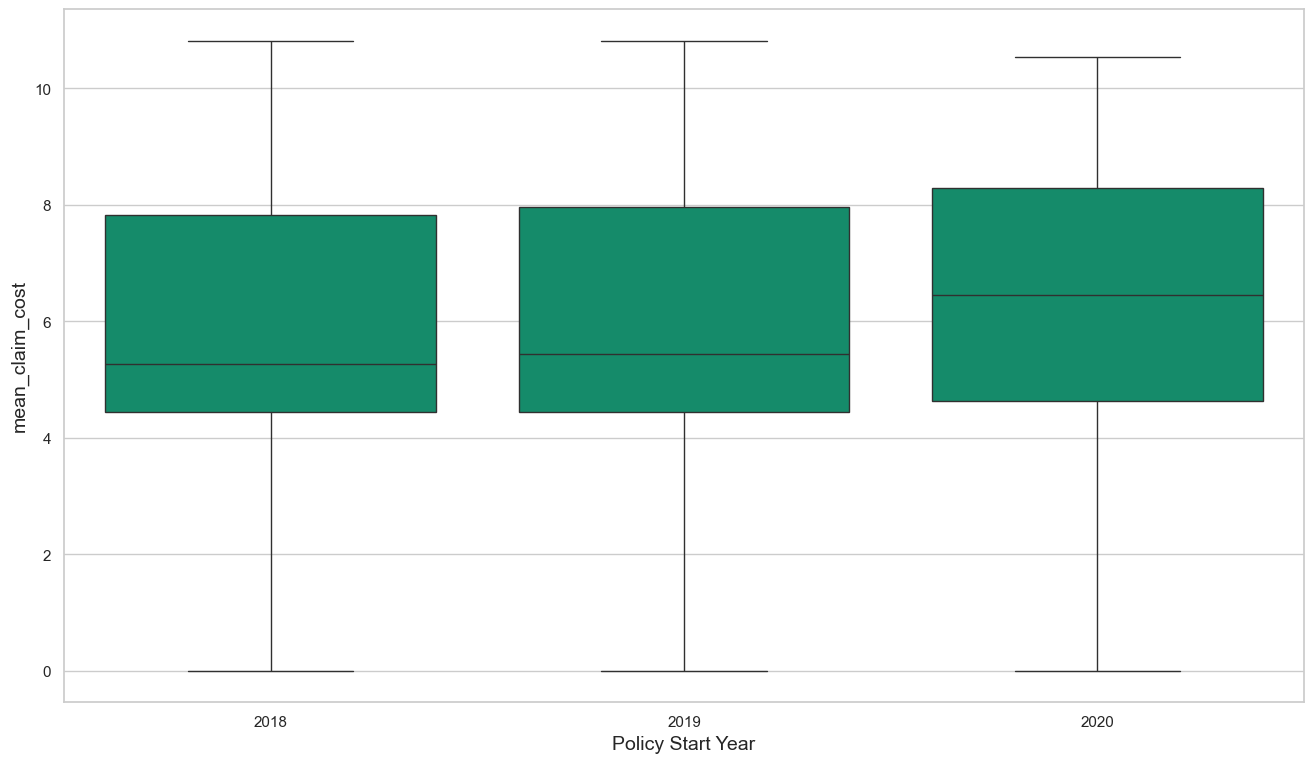

In [30]:
fig = plt.figure(figsize = (16,9))

sns.boxplot(data = df_claimed,
            x = "start_year",
            y = np.log1p(df_claimed["mean_claim_value"]),
            color = sns.color_palette("colorblind")[2])
            
plt.xlabel("Policy Start Year", fontsize = 14)
plt.ylabel("mean_claim_cost", fontsize = 14)

plt.show()

### Type of Claims Made

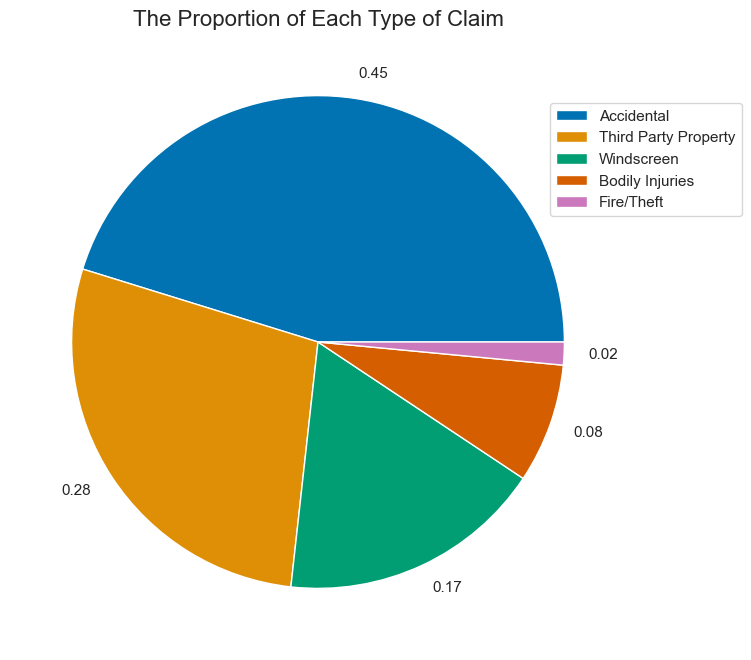

In [31]:
# Calculating the number of each claim type made
claims_by_type = (
    df_claimed.loc[:, ["bi_count", "ad_count", "pd_count", "th_count", "ws_count"]].sum()
    .reset_index()
)
claims_by_type.columns = ["Type", "Frequency"]

#Replacing values
claims_by_type["Type"] = claims_by_type["Type"].str.replace(
    {
        "ad_count":"Accidental",
        "pd_count":"Third Party Property",
        "ws_count":"Windscreen",
        "bi_count":"Bodily Injuries",
        "th_count": "Fire/Theft"
    }
)
#Sorting by descending frequency
claims_by_type = claims_by_type.sort_values("Frequency", ascending=False)

# Calculating Proportion
claims_by_type["Proportion"] = claims_by_type["Frequency"] / claims_by_type["Frequency"].sum()


#Plotting a pie chart
fig = plt.figure(figsize = (8, 8))

plt.pie(data = claims_by_type,
        x = "Proportion",
        labels = round(claims_by_type["Proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"], loc='upper right', bbox_to_anchor=(1.2, 0.9))
plt.title("The Proportion of Each Type of Claim", fontsize = 16)

plt.show()

### Identifying Customers to Reduce NCD

In [32]:
ncd_to_reduce = (
    df_claimed[(df_claimed["ncd"] > 0) & (df_claimed["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

ncd_to_reduce.head()

,id,ncd,pncd,claim_count
0,61956,6,N,1
1,35145,3,N,1
2,93633,9,N,1
3,54363,1,N,1
4,59231,2,N,1


### Identifying Customers to Promote PNCD

In [33]:
offer_pncd = (
    df[(df["claim_count"] == 0) & (df["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

offer_pncd.head()

,id,ncd,pncd,claim_count
0,16042,0,N,0
1,65415,0,N,0
2,89268,8,N,0
3,47359,9,N,0
4,22527,0,N,0


## Investigating Severity by Factors

### Severity by Vehicle-use

In [34]:
severity_by_use = (
    df_claimed.groupby("vehicle_use")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
)
severity_by_use["severity"] = severity_by_use["total_incurred"] / severity_by_use["claims"]

severity_by_use

,total_incurred,claims,severity
vehicle_use,,,
B,32077.70,16,2004.856250
C,13006505.81,5354,2429.306278
S,6568510.64,2564,2561.821622


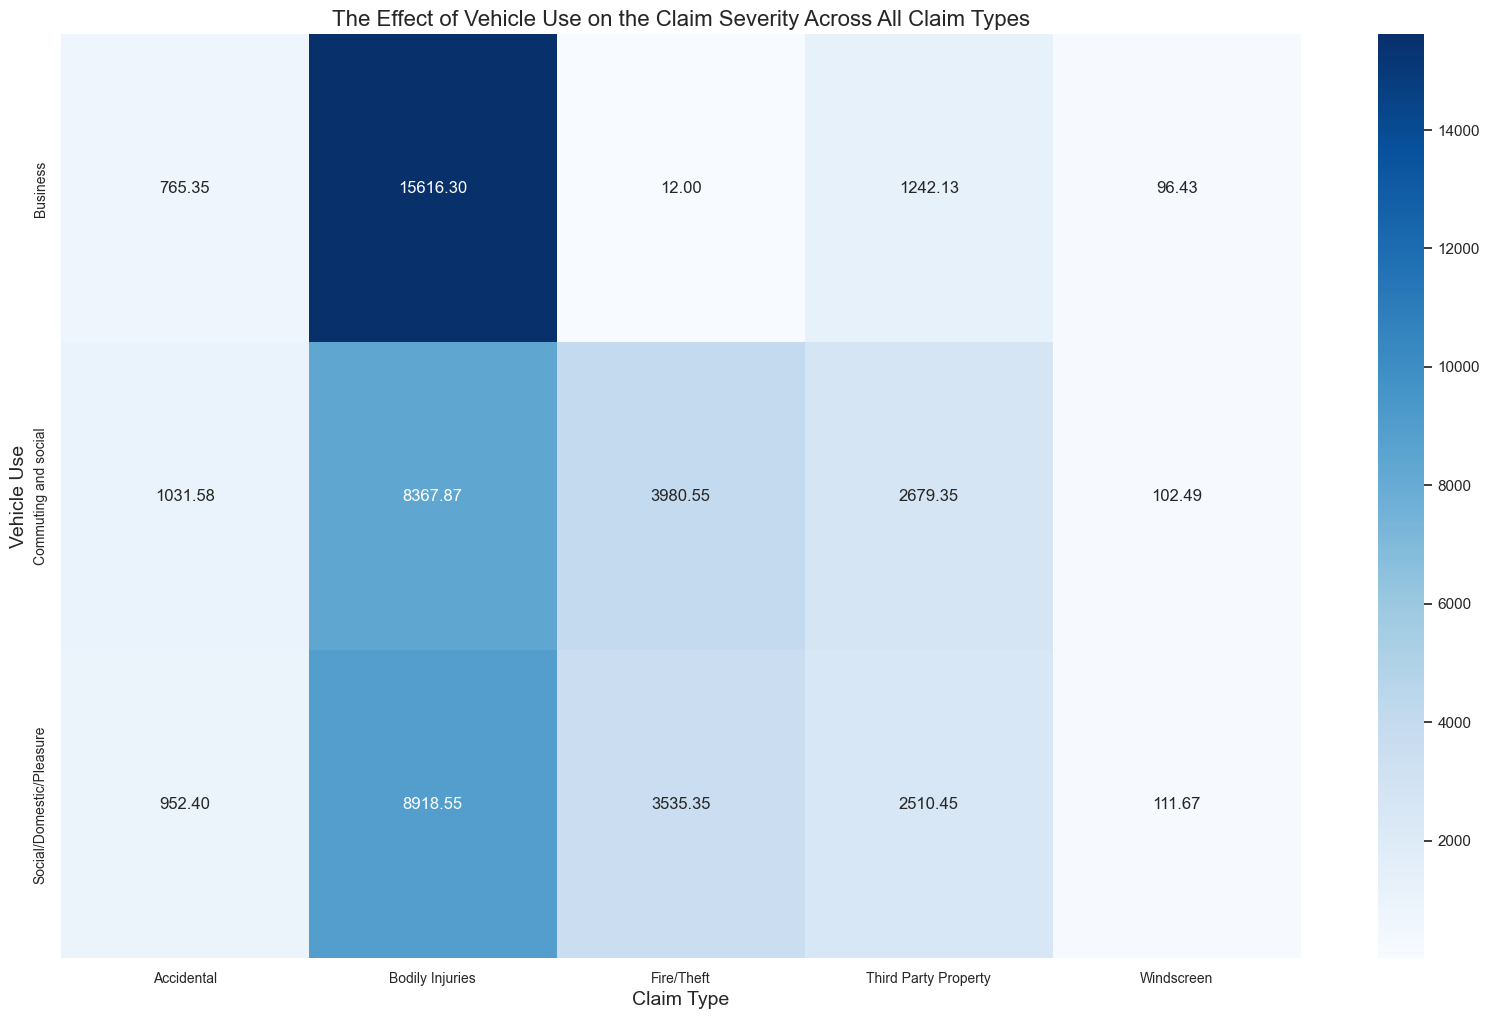

In [35]:
severity_by_use_type, s_pivot = severity_calc(df = df_claimed,
                                              by_group = "vehicle_use",
                                              key = {
                                                  "B":"Business",
                                                  "C":"Commuting and social",
                                                  "S":"Social/Domestic/Pleasure"
                                              }
)

s_pivot = s_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Use", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Use on the Claim Severity Across All Claim Types", fontsize = 16)

plt.show()

### Severity by Overnight Location

In [36]:
severity_by_loc = (
    df_claimed.groupby("overnight_location")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
)
severity_by_loc["severity"] = severity_by_loc["total_incurred"] / severity_by_loc["claims"]

severity_by_loc

,total_incurred,claims,severity
overnight_location,,,
D,12111607.90,5097,2376.222857
G,1267561.80,418,3032.444498
R,6227924.45,2419,2574.586379


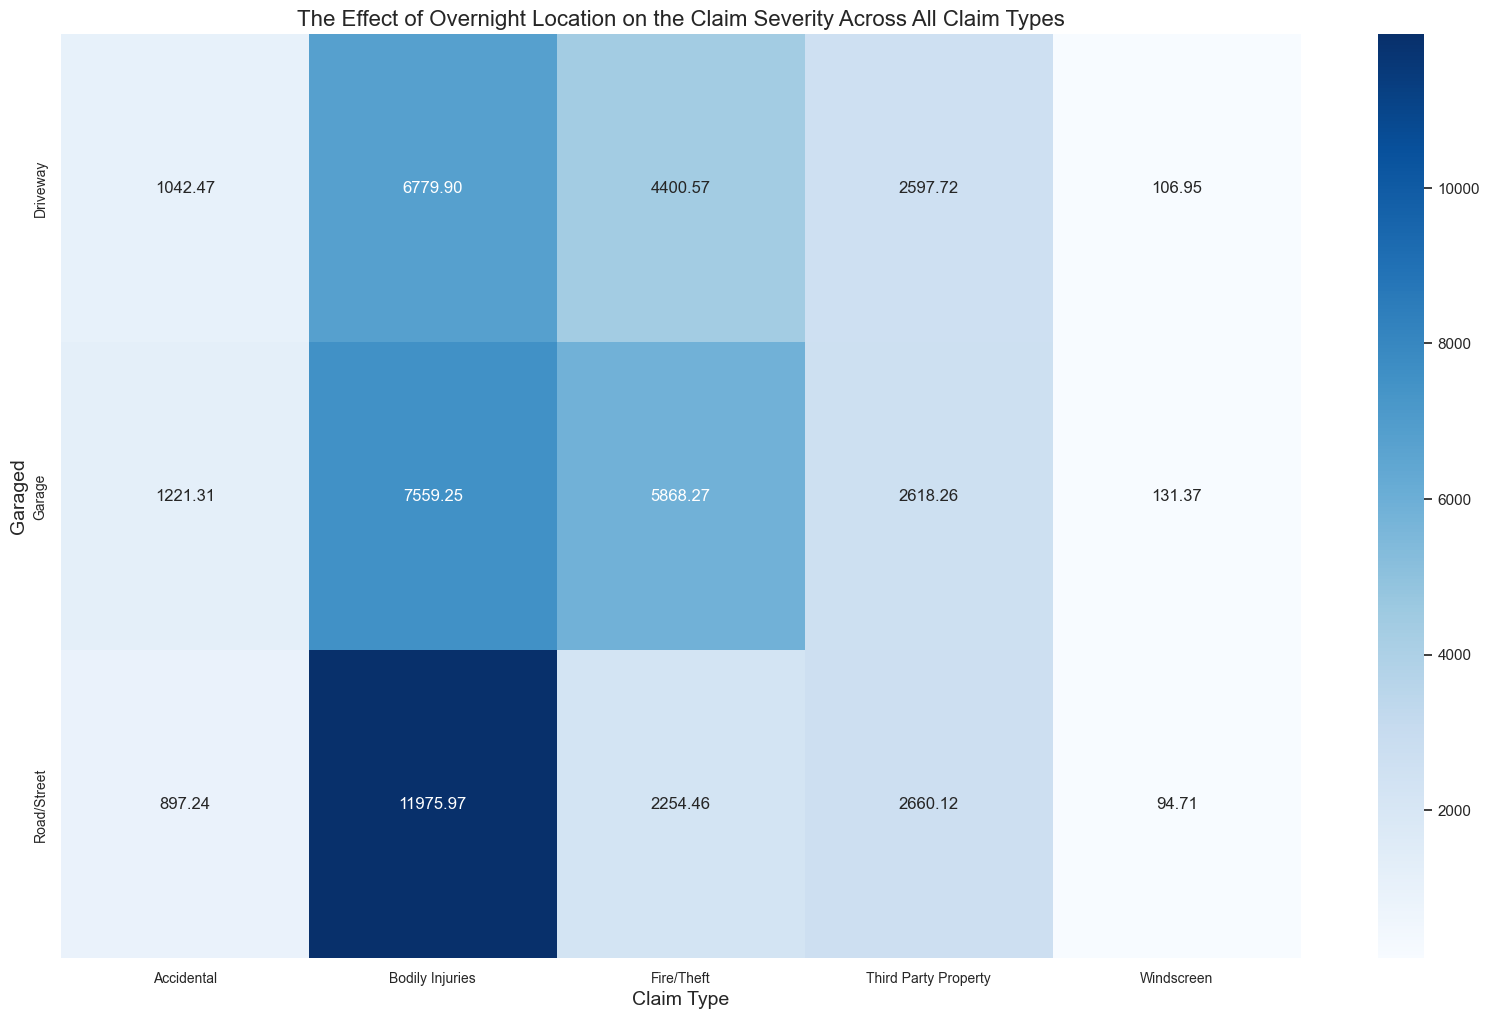

In [37]:
severity_by_loc_type, s_pivot2 = severity_calc(df = df_claimed,
                                              by_group = "overnight_location",
                                              key = {
                                                  "D":"Driveway",
                                                  "G":"Garage",
                                                  "R":"Road/Street"
                                              }
)

s_pivot2 = s_pivot2.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot2,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Garaged", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Overnight Location on the Claim Severity Across All Claim Types", fontsize = 16)

plt.show()

### Severity by Experience

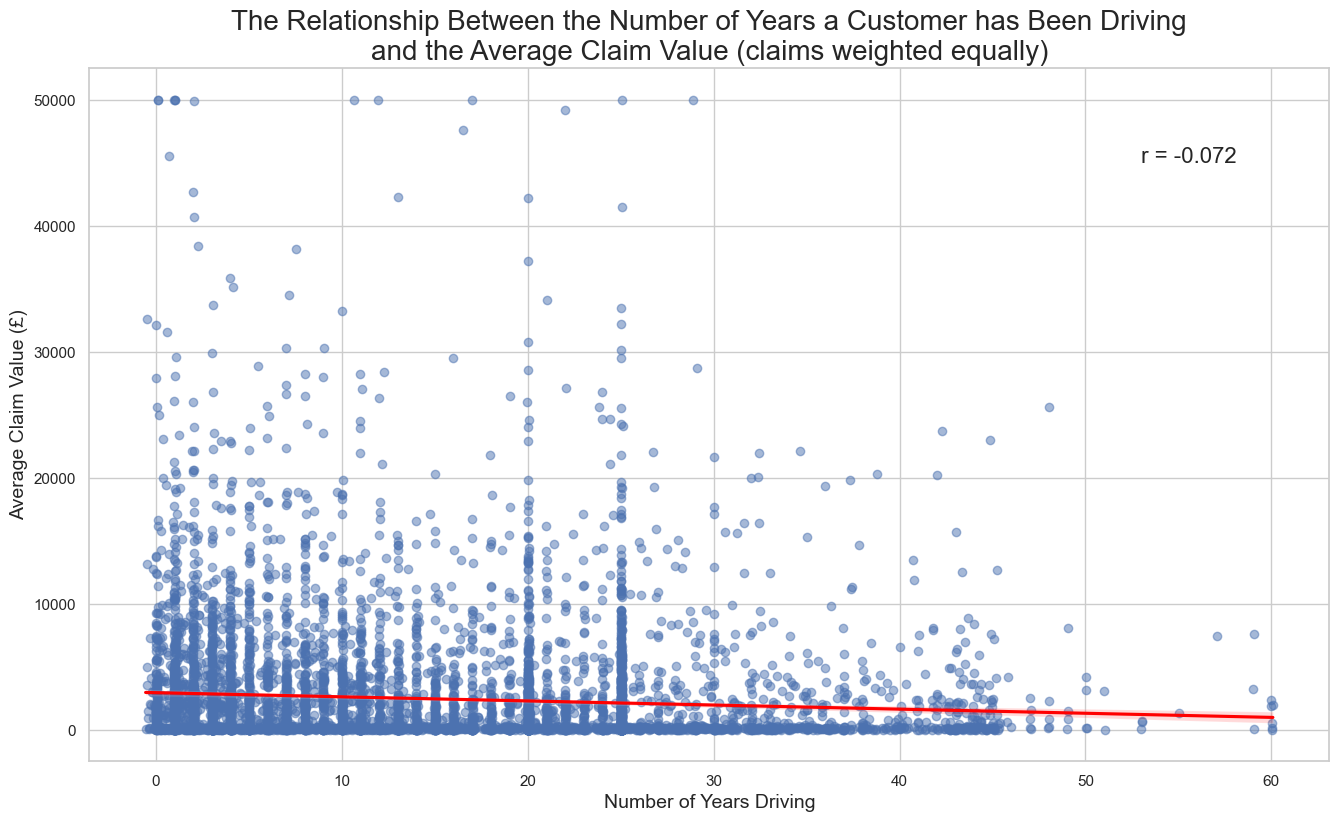

In [38]:
r = df_claimed["years_driving"].corr(df_claimed["mean_claim_value"])

plt.figure(figsize=(16, 9))

sns.regplot(
    data=df_claimed,
    x="years_driving",
    y="mean_claim_value",
    scatter_kws={"alpha": 0.5},
    line_kws={"color":"red"}
)
plt.text(x = 53,
        y = 45000,
        s = f"r = {round(r, 3)}",
        fontsize = 16)

plt.xlabel("Number of Years Driving", fontsize = 14)
plt.ylabel("Average Claim Value (£)", fontsize = 14)
plt.title('''The Relationship Between the Number of Years a Customer has Been Driving
and the Average Claim Value (claims weighted equally)''',
         fontsize = 20)

plt.show()

In [39]:
severity_by_exp = (
    df_claimed.groupby("experience_group")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
)
severity_by_exp["severity"] = severity_by_exp["total_incurred"] / severity_by_exp["claims"]

severity_by_exp

,total_incurred,claims,severity
experience_group,,,
<0 years,162079.90,47,3448.508511
0-10 years,9617101.77,3320,2896.717401
10-20 years,4037696.29,1833,2202.780300
20-30 years,4466523.09,2097,2129.958555
30-40 years,825443.13,399,2068.779774
40-50 years,459698.73,218,2108.709771
50-60 years,33614.38,15,2240.958667
60+ years,4936.86,5,987.372000


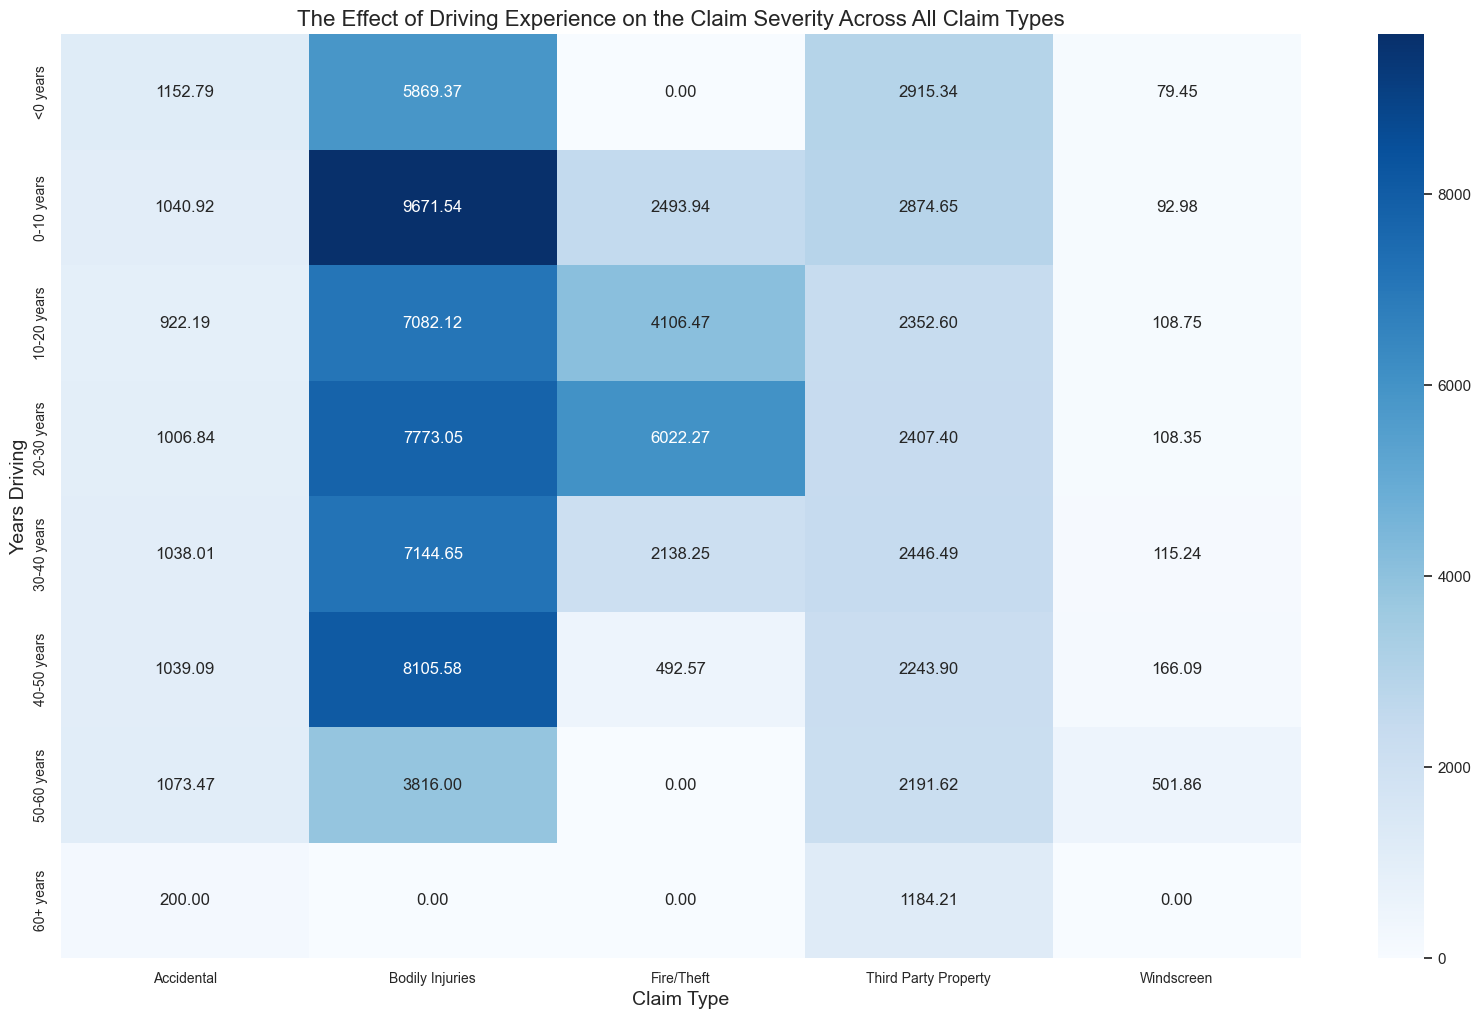

In [40]:
severity_by_exp_type, s_pivot3 = severity_calc(df = df_claimed,
                                              by_group = "experience_group")

s_pivot3 = s_pivot3.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot3,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Years Driving", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Driving Experience on the Claim Severity Across All Claim Types", fontsize = 16)

plt.show()

### Severity by Vehicle Value

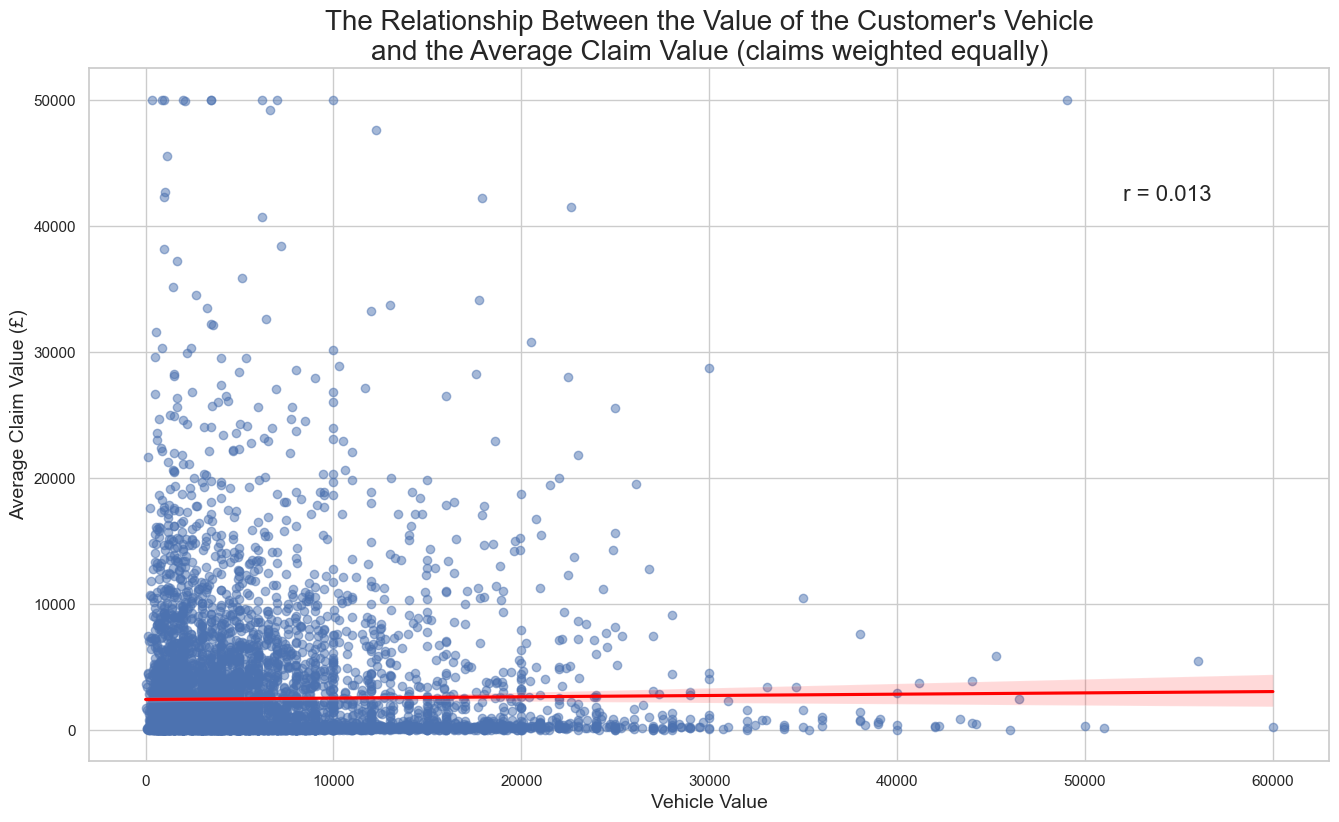

In [41]:
r2 = df_claimed["vehicle_value"].corr(df_claimed["mean_claim_value"])

plt.figure(figsize=(16, 9))

sns.regplot(
    data=df_claimed,
    x="vehicle_value",
    y="mean_claim_value",
    scatter_kws={"alpha": 0.5},
    line_kws={"color":"red"}
)
plt.text(x = 52000,
       y = 42000,
         s = f"r = {round(r2, 3)}",
         fontsize = 16)

plt.xlabel("Vehicle Value", fontsize = 14)
plt.ylabel("Average Claim Value (£)", fontsize = 14)
plt.title('''The Relationship Between the Value of the Customer's Vehicle
and the Average Claim Value (claims weighted equally)''',
         fontsize = 20)

plt.show()

In [42]:
severity_by_value = (
    df_claimed.groupby("vehicle_value_band")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
)
severity_by_value["severity"] = severity_by_value["total_incurred"] / severity_by_value["claims"]

severity_by_value

,total_incurred,claims,severity
vehicle_value_band,,,
£0-2000,5771204.81,2221,2598.471324
£2000-4000,4022625.21,1699,2367.642855
£4000-6000,2849603.71,1279,2227.993518
£6000-8000,1979005.26,843,2347.574448
£8000-10000,1487480.60,557,2670.521724
£10000+,3497174.56,1335,2619.606412


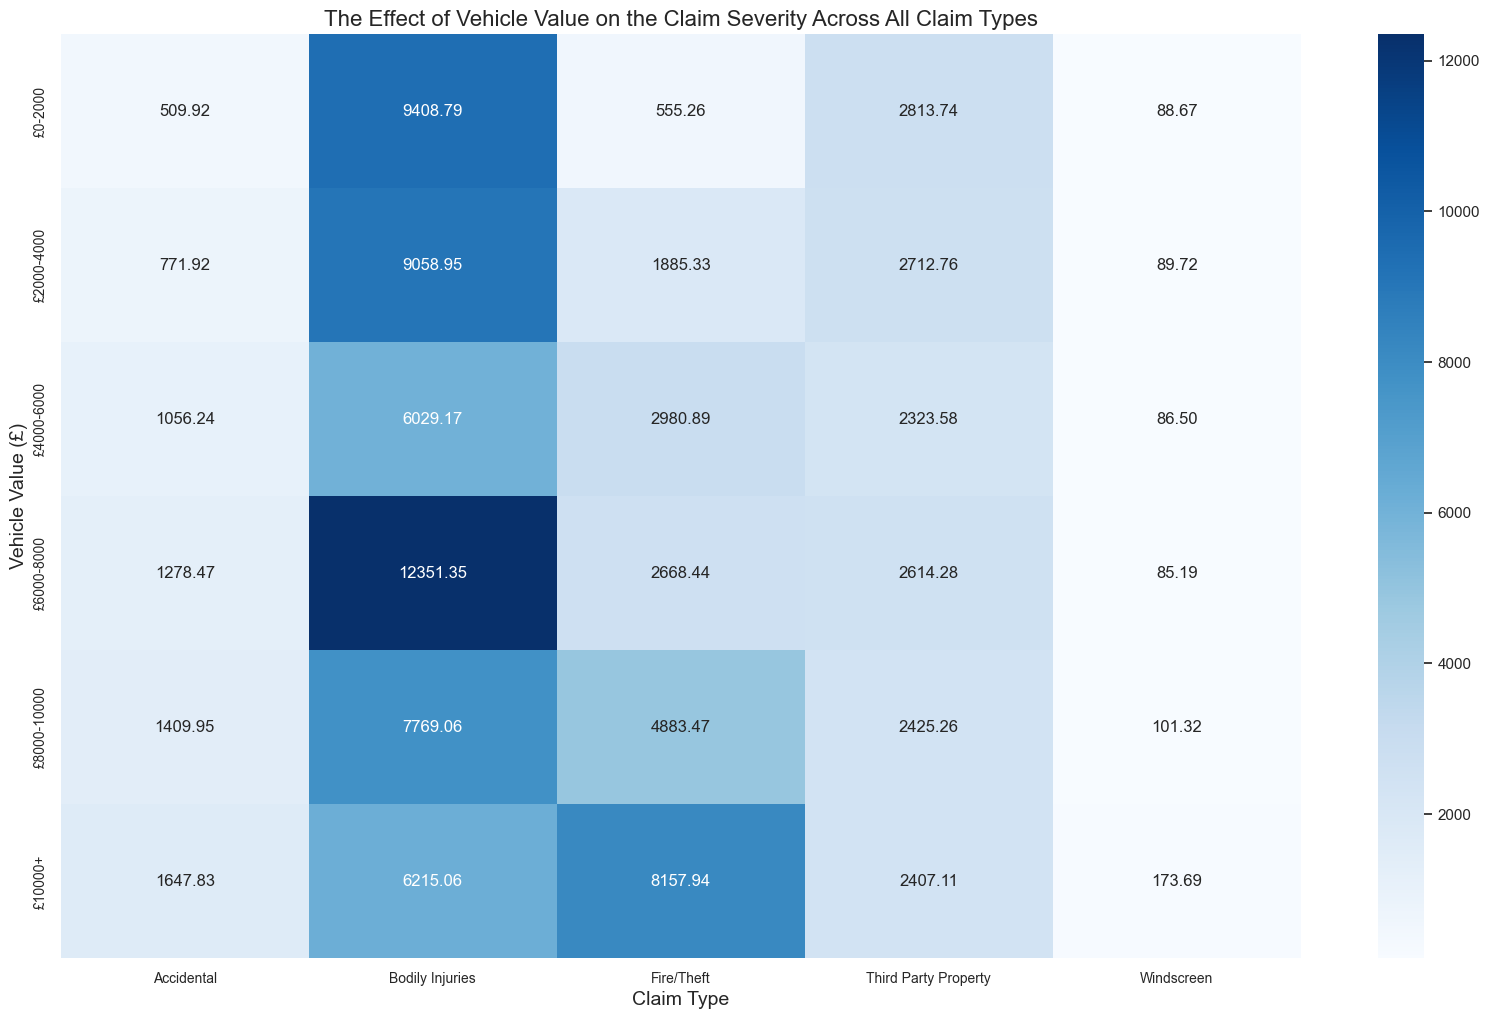

In [43]:
severity_by_value_type, s_pivot4 = severity_calc(df = df_claimed,
                                              by_group = "vehicle_value_band")

s_pivot4 = s_pivot4.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot4,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Value (£)", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Value on the Claim Severity Across All Claim Types", fontsize = 16)

plt.show()

### Severity by Region

In [44]:
severity_by_region = (
    df_claimed.groupby("region")
    .agg(
        total_incurred = ("final_incurred", "sum"),
        claims = ("claim_count", "sum")
    )
)
severity_by_region["severity"] = severity_by_region["total_incurred"] / severity_by_region["claims"]

severity_by_region

,total_incurred,claims,severity
region,,,
East Anglia,779834.40,453,1721.488742
East Midlands,1079193.73,526,2051.699106
London,739056.88,263,2810.102205
N Ireland,332980.88,115,2895.485913
North,1507419.15,508,2967.360531
North West,2984348.22,1033,2889.010862
Outer London,1120075.96,445,2517.024629
Scotland,981789.35,360,2727.192639
South East,3124859.59,1378,2267.677496


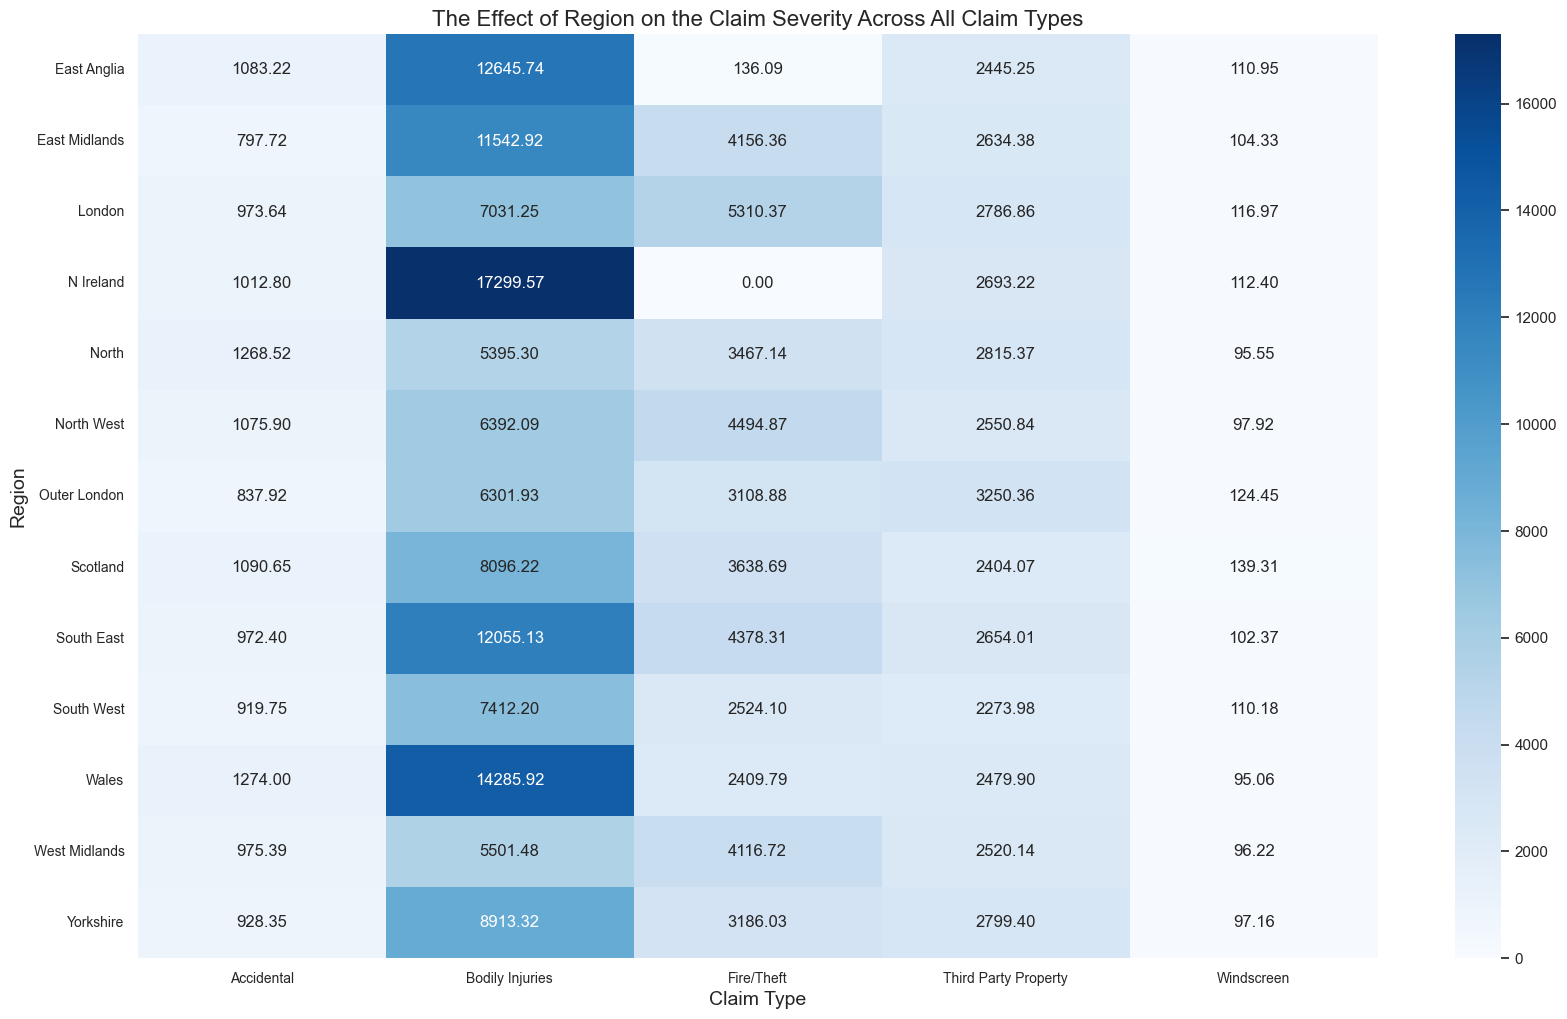

In [45]:
severity_by_region_type, s_pivot5 = severity_calc(df = df_claimed,
                                              by_group = "region")

s_pivot5 = s_pivot5.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = s_pivot5,
            annot=True,
            fmt=".2f",
            cmap="Blues")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Region", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Region on the Claim Severity Across All Claim Types", fontsize = 16)

plt.show()

### Claim Type

In [46]:
# Aggregating by Claim Type

by_claim_type = (
    df_claimed.loc[:, ["bi_incurred", "ad_incurred", "pd_incurred", "th_incurred", "ws_incurred"]]
        .sum()
        .reset_index()
        .rename(columns={"index":"Type", 0:"total_incurred"})
    
)
by_claim_type["proportion"] = round((by_claim_type["total_incurred"] / by_claim_type["total_incurred"].sum()), 2)

by_claim_type = by_claim_type.sort_values("total_incurred", ascending = False)

by_claim_type["Type"] = by_claim_type["Type"].str.replace(
    {
        "ad_incurred":"Accidental",
        "pd_incurred":"Third Party Property",
        "ws_incurred":"Windscreen",
        "bi_incurred":"Bodily Injuries",
        "th_incurred": "Fire/Theft"
    }
)

by_claim_type = (
    by_claim_type.set_index('Type')
       .reindex(claims_by_type['Type'])
       .reset_index()
)

by_claim_type

,Type,total_incurred,proportion
0,Accidental,4969271.36,0.23
1,Third Party Property,8023300.89,0.38
2,Windscreen,200168.46,0.01
3,Bodily Injuries,7339314.17,0.35
4,Fire/Theft,619012.96,0.03


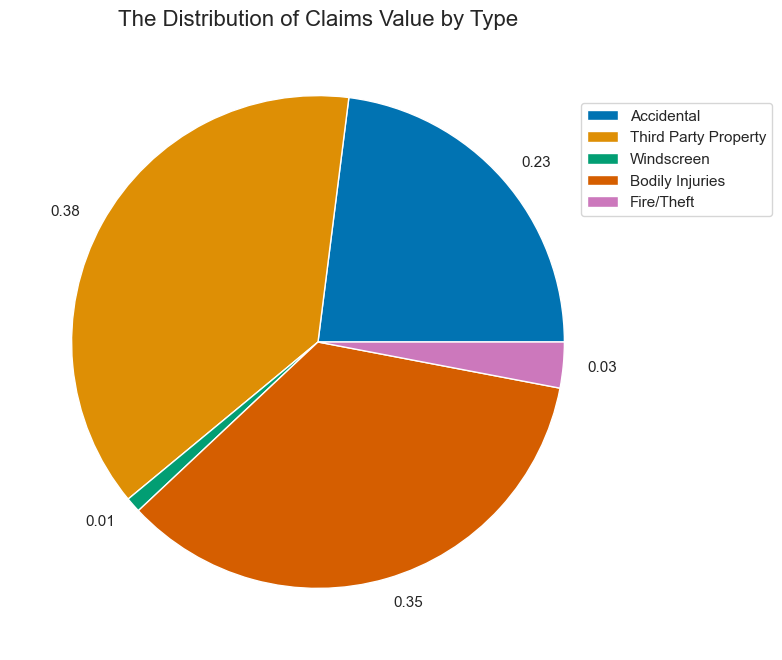

In [47]:
fig = plt.figure(figsize = (8, 8))

plt.pie(data = by_claim_type,
        x = "proportion",
        labels = round(by_claim_type["proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"], loc='upper right', bbox_to_anchor=(1.25, 0.9))
plt.title("The Distribution of Claims Value by Type", fontsize = 16)

plt.show()

## Investigating Frequency by the Same Factors

### Frequency by Vehicle Use

In [48]:
frequency_by_use = (
    df.groupby("vehicle_use")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
)
frequency_by_use["frequency"] = frequency_by_use["claims"] / frequency_by_use["total_exposure"]

frequency_by_use

,total_exposure,claims,frequency
vehicle_use,,,
B,150.838851,16,0.106073
C,45955.546322,5354,0.116504
S,25853.089141,2564,0.099176


In [49]:
frequency_by_use_type, f_pivot = frequency_calc(df = df,
                                                   by_group = "vehicle_use",
                                                   key = {
        "B":"Business",
        "C":"Commuting and social",
        "S":"Social/Domestic/Pleasure"
    })

f_pivot

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
vehicle_use,,,,,
Business,0.086185,0.00663,0.00663,0.033148,0.019889
Commuting and social,0.072548,0.012273,0.002089,0.043499,0.029398
Social/Domestic/Pleasure,0.061733,0.011295,0.002592,0.041001,0.021274


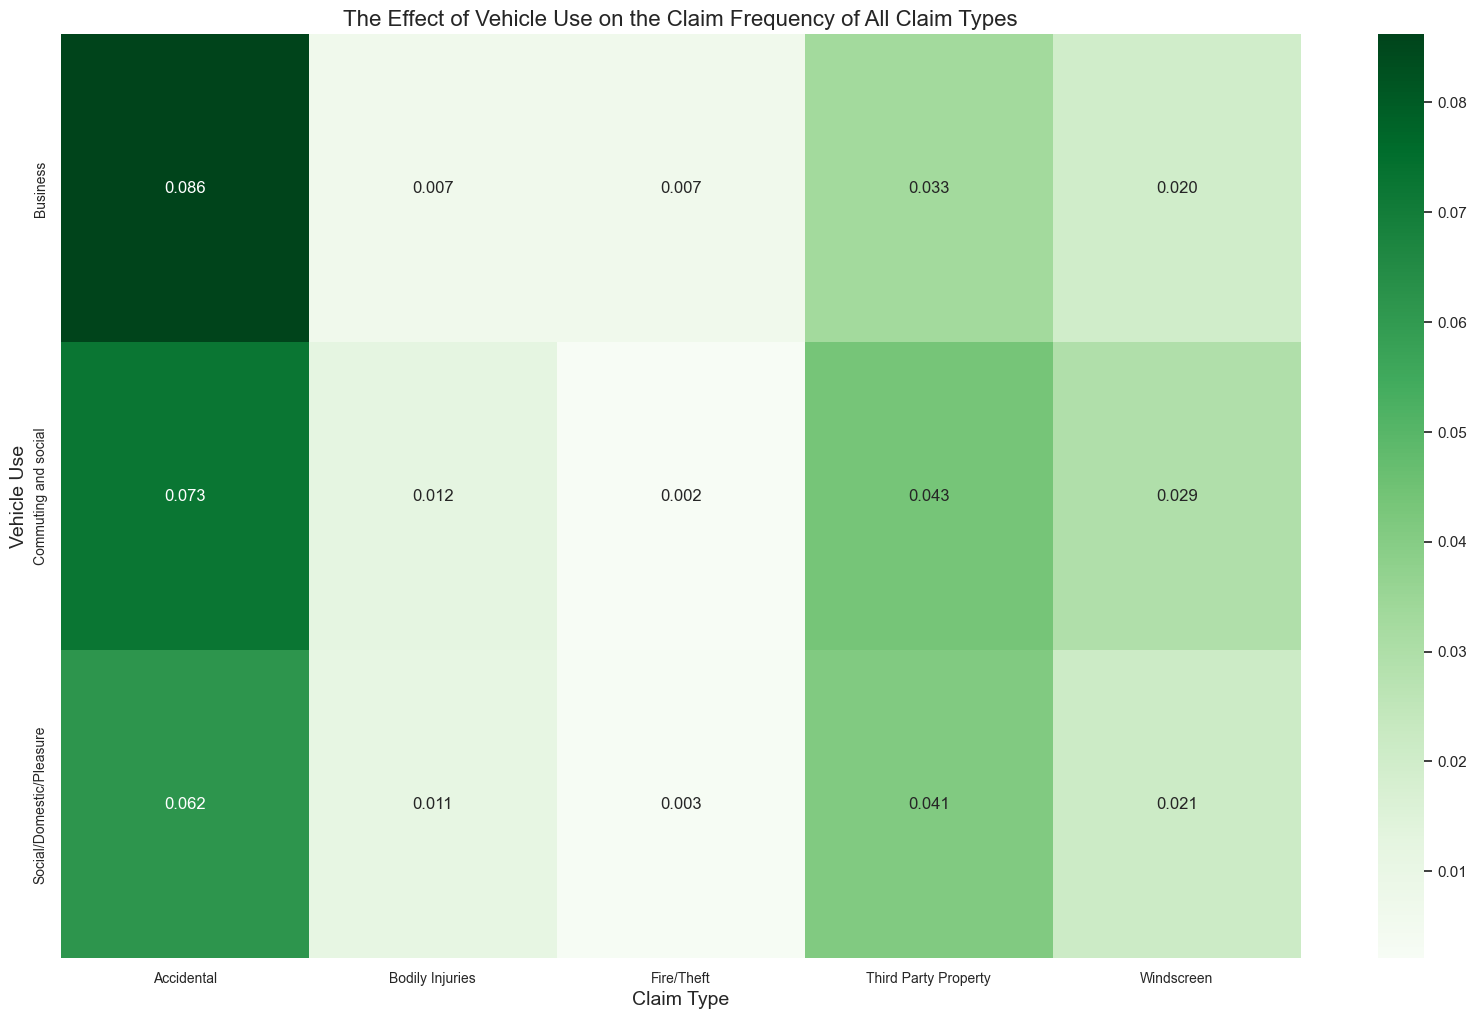

In [50]:
f_pivot = f_pivot.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Use", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Use on the Claim Frequency of All Claim Types", fontsize = 16)

plt.show()

### Frequency by Overnight Location

In [51]:
frequency_by_loc = (
    df.groupby("overnight_location")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
)
frequency_by_loc["frequency"] = frequency_by_loc["claims"] / frequency_by_loc["total_exposure"]

frequency_by_loc

,total_exposure,claims,frequency
overnight_location,,,
D,47037.240261,5097,0.108361
G,4489.268472,418,0.093111
R,20432.965581,2419,0.118387


In [52]:
frequency_by_loc_type, f_pivot2 = frequency_calc(df = df,
                                                   by_group = "overnight_location",
                                                   key = {
        "D":"Driveway",
        "G":"Garage",
        "R":"Road/Street"
    })

frequency_by_loc_type

,overnight_location,total_exposure,claims,frequency,claim_type
0,Driveway,47037.240261,3096,0.06582,Accidental
1,Garage,4489.268472,261,0.058139,Accidental
2,Road/Street,20432.965581,1586,0.07762,Accidental
3,Driveway,47037.240261,516,0.01097,Bodily Injuries
4,Garage,4489.268472,55,0.012251,Bodily Injuries
5,Road/Street,20432.965581,286,0.013997,Bodily Injuries
6,Driveway,47037.240261,1920,0.040819,Third Party Property
7,Garage,4489.268472,179,0.039873,Third Party Property
8,Road/Street,20432.965581,965,0.047228,Third Party Property
9,Driveway,47037.240261,101,0.002147,Fire/Theft


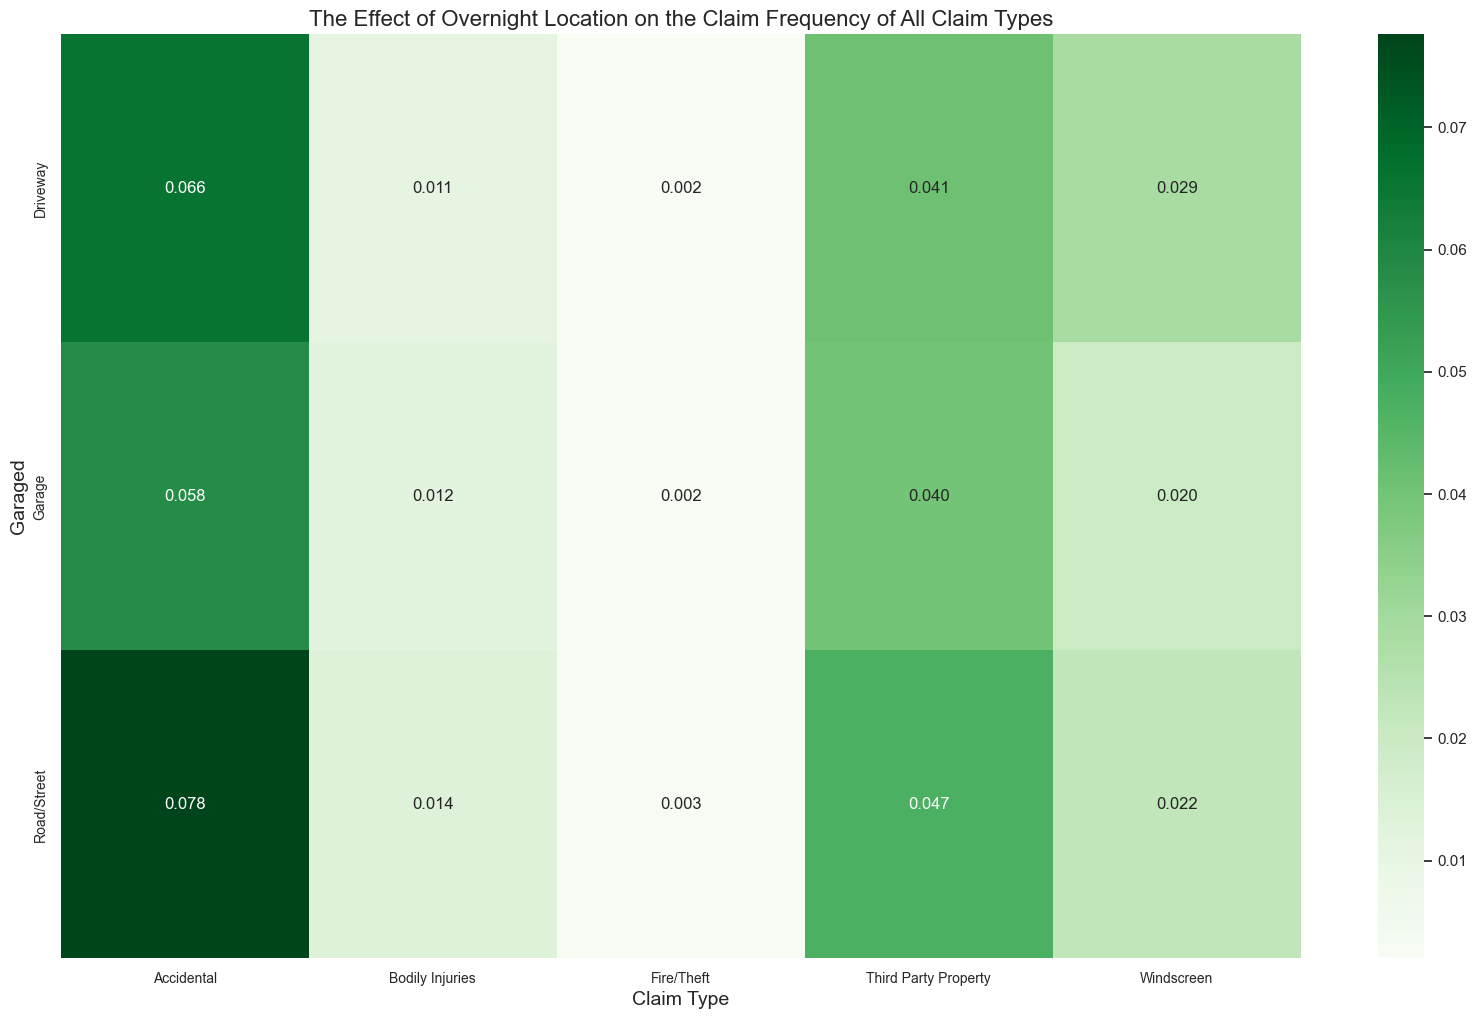

In [53]:
f_pivot2 = f_pivot2.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot2,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Garaged", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Overnight Location on the Claim Frequency of All Claim Types", fontsize = 16)

plt.show()

### Frequency by Experience

In [54]:
frequency_by_exp = (
    df.groupby("experience_group")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
)
frequency_by_exp["frequency"] = frequency_by_exp["claims"] / frequency_by_exp["total_exposure"]

frequency_by_exp

,total_exposure,claims,frequency
experience_group,,,
<0 years,365.120436,47,0.128725
0-10 years,24883.557831,3320,0.133421
10-20 years,16001.789919,1833,0.114550
20-30 years,22682.314090,2097,0.092451
30-40 years,4802.988709,399,0.083073
40-50 years,2946.164704,218,0.073995
50-60 years,227.600861,15,0.065905
60+ years,47.429224,5,0.105420


In [55]:
frequency_by_exp_type, f_pivot3 = frequency_calc(df = df,
                                                 by_group = "experience_group")

f_pivot3

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
experience_group,,,,,
<0 years,0.084903,0.024649,0.0,0.068471,0.021911
0-10 years,0.084715,0.017843,0.002371,0.058995,0.027448
10-20 years,0.070492,0.011686,0.002812,0.041245,0.028872
20-30 years,0.057181,0.007539,0.001896,0.029979,0.025571
30-40 years,0.048095,0.006454,0.002498,0.027691,0.023735
40-50 years,0.045483,0.004752,0.001697,0.02953,0.019008
50-60 years,0.057118,0.004394,0.0,0.030756,0.004394
60+ years,0.021084,0.0,0.0,0.084336,0.0


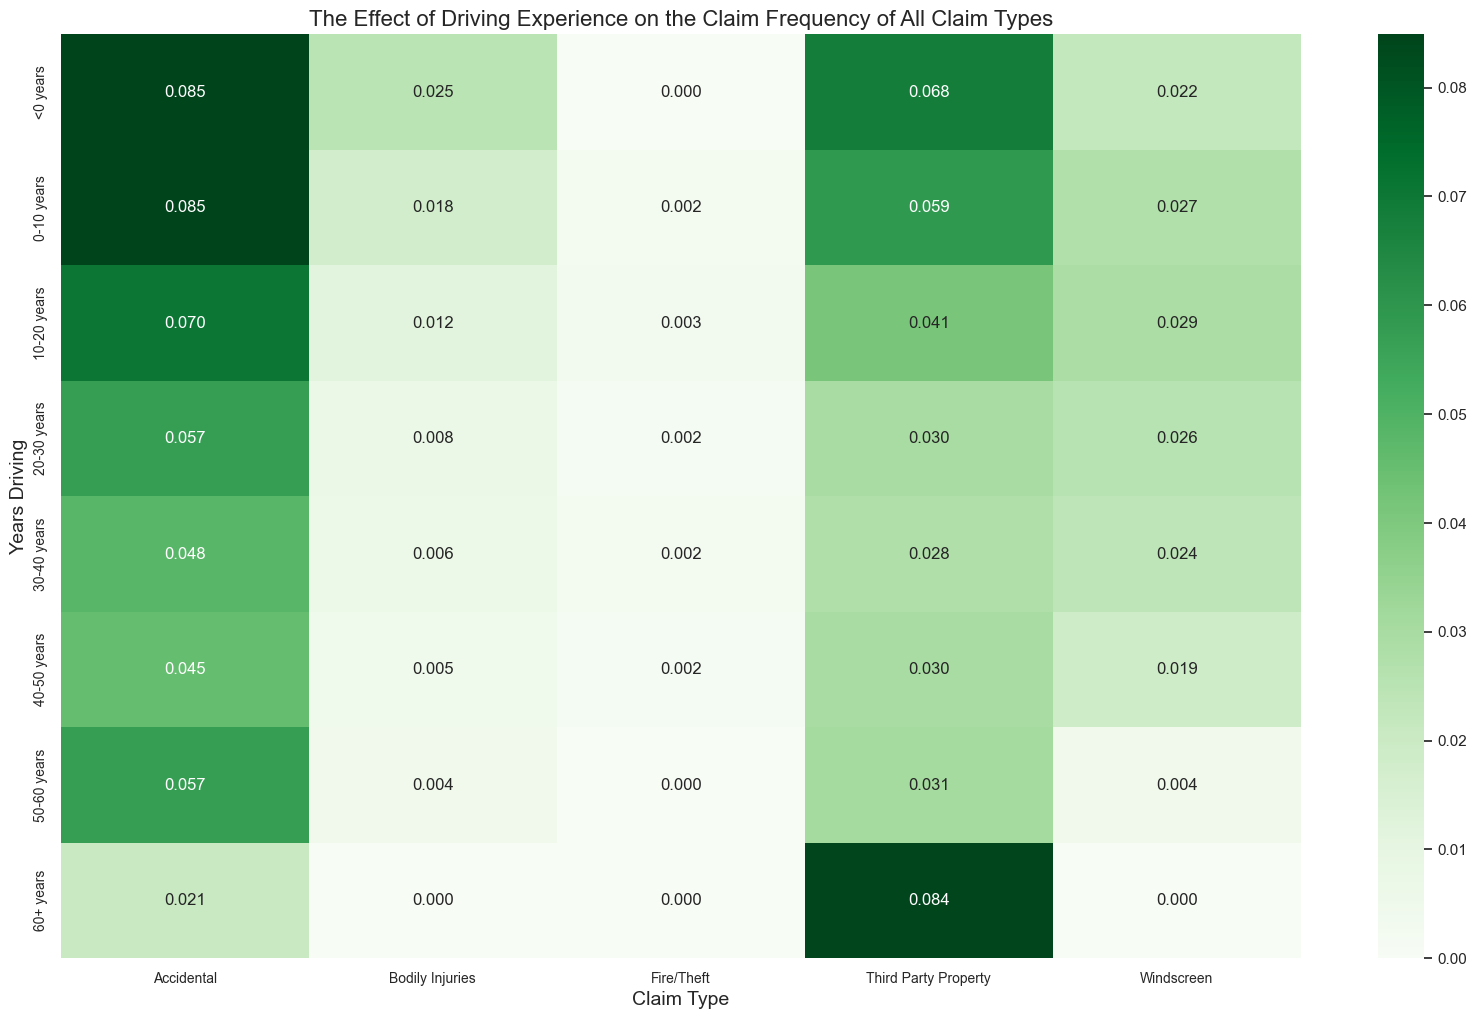

In [56]:
f_pivot3 = f_pivot3.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot3,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Years Driving", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Driving Experience on the Claim Frequency of All Claim Types", fontsize = 16)

plt.show()

### Frequency by Vehicle Value

In [57]:
frequency_by_value = (
    df.groupby("vehicle_value_band")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
)
frequency_by_value["frequency"] = frequency_by_value["claims"] / frequency_by_value["total_exposure"]

frequency_by_value

,total_exposure,claims,frequency
vehicle_value_band,,,
£0-2000,21538.505500,2221,0.103118
£2000-4000,15967.808974,1699,0.106402
£4000-6000,11308.452514,1279,0.113101
£6000-8000,7395.963764,843,0.113981
£8000-10000,4635.103554,557,0.120170
£10000+,11113.640008,1335,0.120123


In [58]:
frequency_by_value_type, f_pivot4 = frequency_calc(df = df,
                                                 by_group = "vehicle_value_band")

f_pivot4

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
vehicle_value_band,,,,,
£0-2000,0.059614,0.013743,0.001718,0.048657,0.021589
£2000-4000,0.066634,0.012212,0.001941,0.041521,0.02599
£4000-6000,0.074192,0.011142,0.001945,0.042358,0.025733
£6000-8000,0.075987,0.00987,0.001893,0.036236,0.02934
£8000-10000,0.071627,0.012297,0.003452,0.042933,0.034519
£10000+,0.077562,0.009898,0.003959,0.036622,0.032033


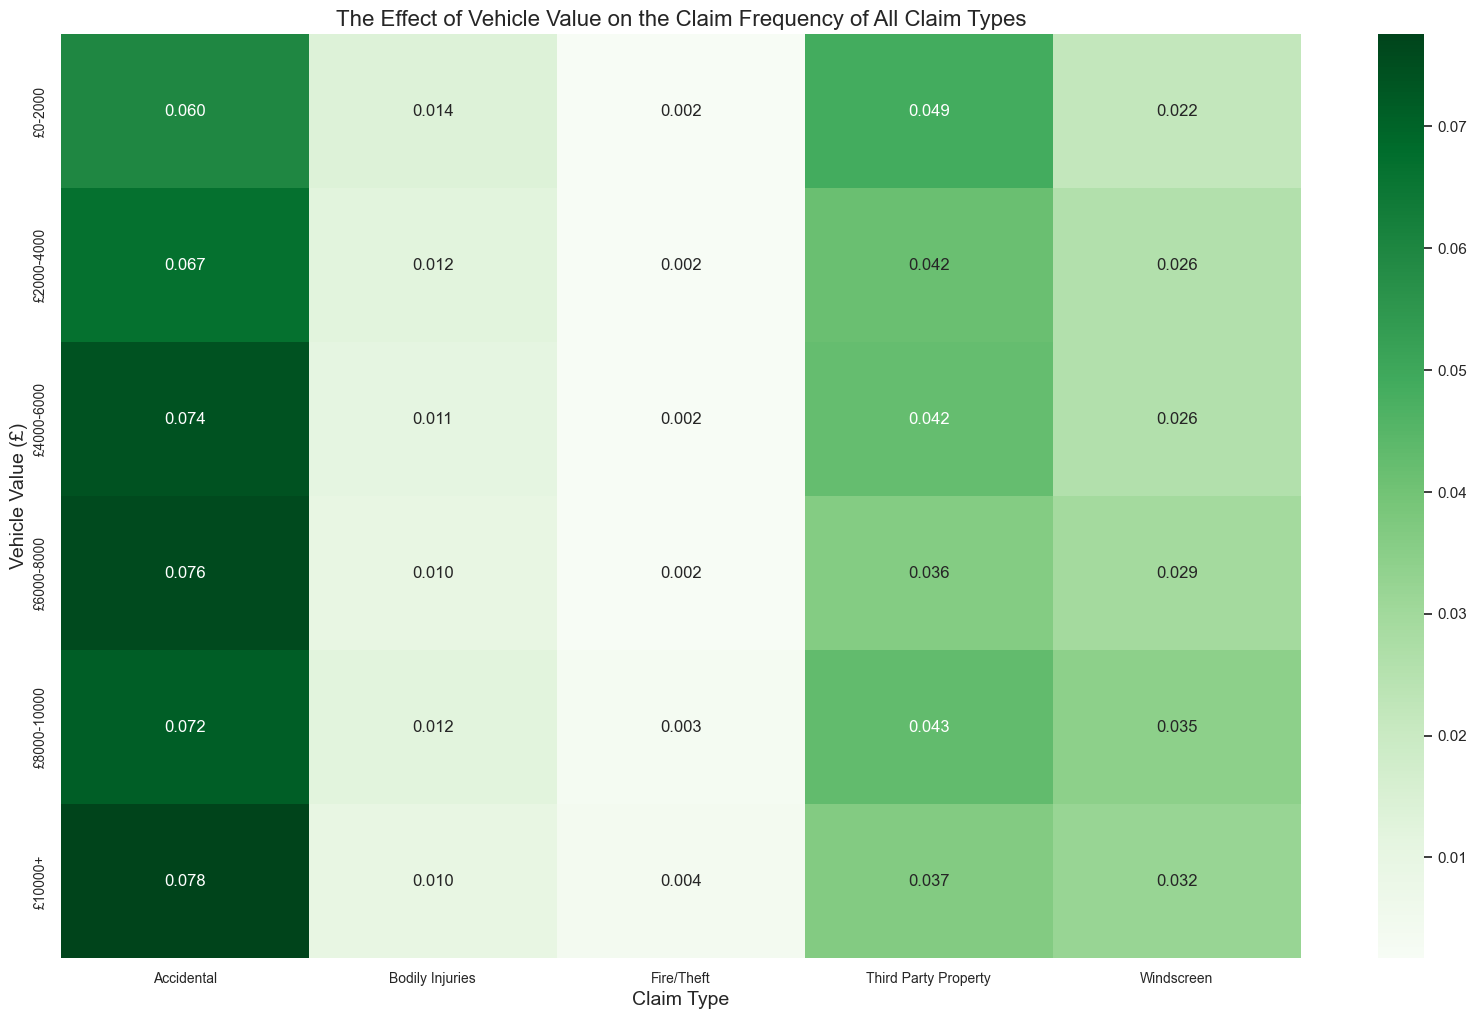

In [59]:
f_pivot4 = f_pivot4.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot4,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Vehicle Value (£)", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Vehicle Value on the Claim Frequency of All Claim Types", fontsize = 16)

plt.show()

### Frequency by Region

In [60]:
frequency_by_region = (
    df.groupby("region")
    .agg(
        total_exposure = ("exposure", "sum"),
        claims = ("claim_count", "sum")
    )
)
frequency_by_region["frequency"] = frequency_by_region["claims"] / frequency_by_region["total_exposure"]

frequency_by_region

,total_exposure,claims,frequency
region,,,
East Anglia,3458.052480,453,0.130999
East Midlands,4429.456118,526,0.118750
London,1965.129621,263,0.133833
N Ireland,1580.801825,115,0.072748
North,5607.805921,508,0.090588
North West,9924.150652,1033,0.104090
Outer London,3503.315498,445,0.127023
Scotland,3689.795597,360,0.097566
South East,11184.643265,1378,0.123205


In [61]:
frequency_by_region_type, f_pivot5 = frequency_calc(df = df,
                                                 by_group = "region")

f_pivot5

claim_type,Accidental,Bodily Injuries,Fire/Theft,Third Party Property,Windscreen
region,,,,,
East Anglia,0.068536,0.007808,0.001446,0.03875,0.052342
East Midlands,0.073372,0.011288,0.003161,0.040186,0.03409
London,0.080911,0.016793,0.004071,0.055467,0.025952
N Ireland,0.044281,0.005693,0.0,0.024038,0.022773
North,0.062591,0.013731,0.00107,0.039053,0.017476
North West,0.064388,0.016626,0.003124,0.042825,0.019246
Outer London,0.084777,0.01256,0.003711,0.047669,0.024548
Scotland,0.065044,0.01057,0.002168,0.041195,0.018971
South East,0.072063,0.010193,0.001967,0.046582,0.034869


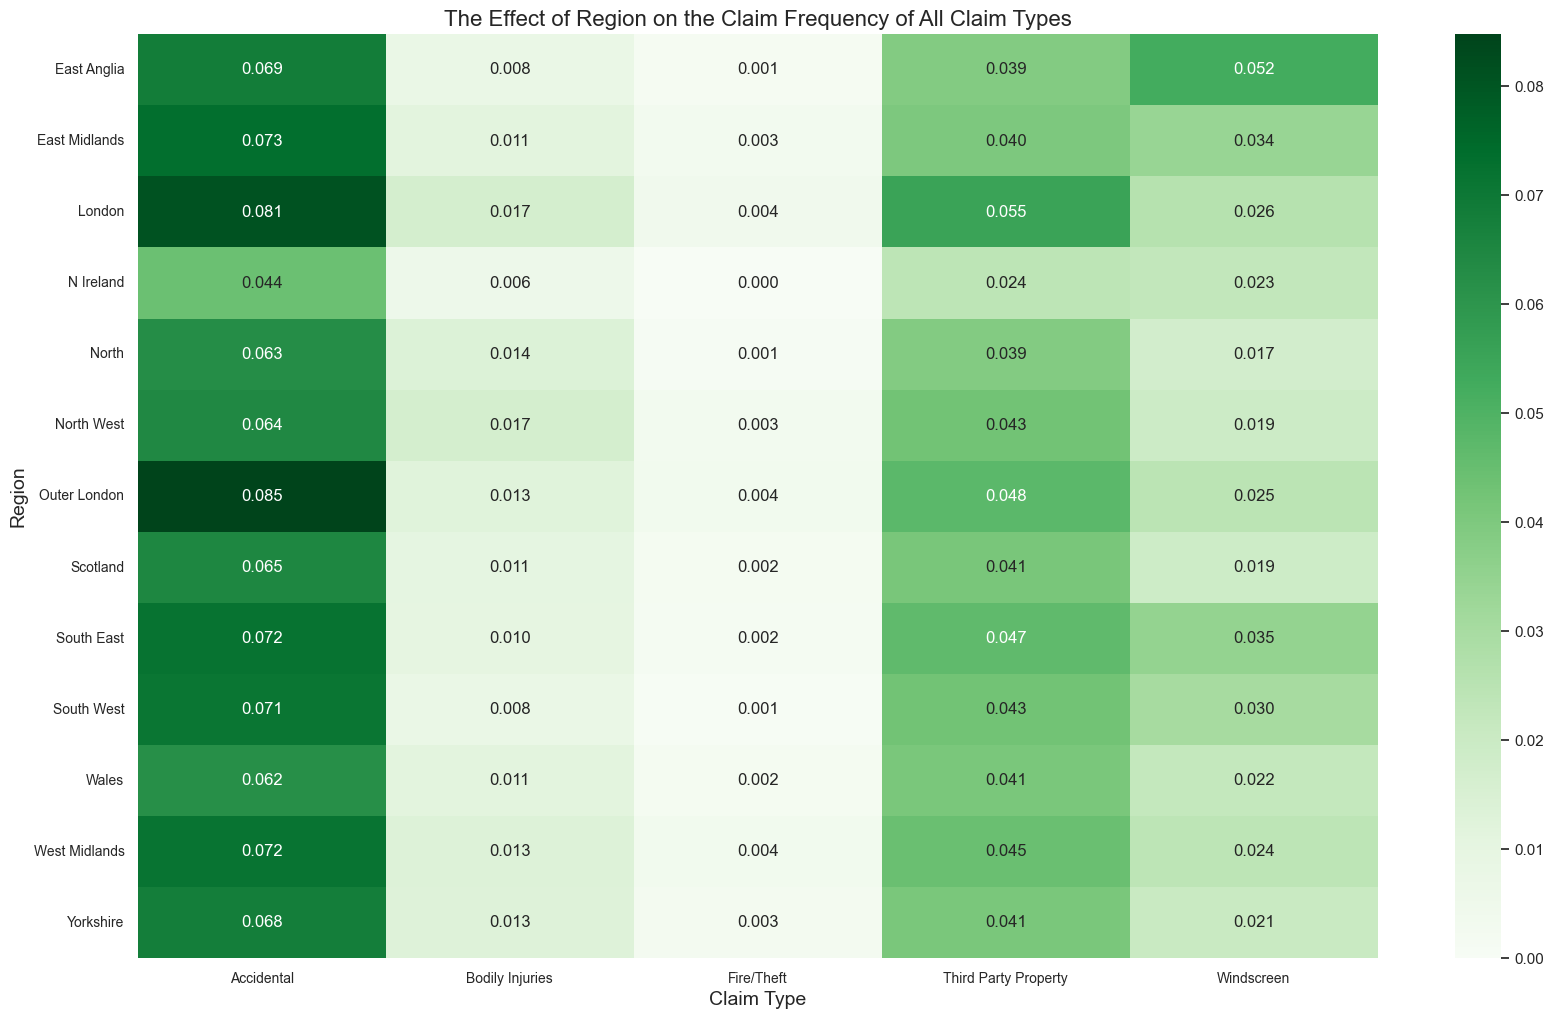

In [62]:
f_pivot5 = f_pivot5.astype("float64")

fig = plt.figure(figsize = (20,12))

sns.heatmap(data = f_pivot5,
            annot=True,
            fmt=".3f",
            cmap="Greens")

plt.xlabel("Claim Type", fontsize = 14)
plt.xticks(fontsize = 10)
plt.ylabel("Region", fontsize = 14)
plt.yticks(fontsize = 10)

plt.title("The Effect of Region on the Claim Frequency of All Claim Types", fontsize = 16)

plt.show()

## Profiling Customers Who Did Not Make Claims

In [63]:
# Identifying "safest" demographic.
df_no_claim = df[df["claim_count"] == 0]

df_no_claim.groupby("gender").id.count()

gender
Female     42515
Male       50064
Unknown        2
Name: id, dtype: int64